<a href="https://colab.research.google.com/github/farrelrassya/python-for-finance/blob/main/ch12_stochastics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 12 -- Stochastics

> *Predictability is not how things will go, but how they can go.*  -- Raheel Farooq

This notebook accompanies Chapter 12 of **Python for Finance** (2nd ed.) by
Yves Hilpisch. The chapter introduces **stochastics** -- one of the most
important mathematical and numerical disciplines in modern finance -- from a
Python perspective. We cover four major themes:

1. **Random numbers.** Pseudo-random number generation is the foundation of
   every Monte Carlo experiment. We rely on `numpy.random` and study both
   uniform and distribution-specific samplers.
2. **Simulation.** We simulate random variables and full *stochastic
   processes*: geometric Brownian motion, the square-root (CIR) diffusion,
   the Heston stochastic-volatility model, and the Merton jump-diffusion
   model.
3. **Valuation.** We price options under both **European** exercise (single
   exercise date $T$) and **American/Bermudan** exercise (an optimal stopping
   problem solved by Longstaff-Schwartz Least-Squares Monte Carlo).
4. **Risk measures.** We estimate **value-at-risk (VaR)** and **credit
   valuation adjustments (CVA)** by Monte Carlo simulation.

**Why stochastics matters in finance.** In the 1970s-1980s, the goal of
financial research was largely to find closed-form solutions, e.g. the
Black-Scholes-Merton formula for a European call. Modern requirements are
much broader: consistent valuation of an entire derivatives book, firm-wide
risk measures (VaR, CVA), and exotic path-dependent or American-style
payoffs. These tasks have no closed-form solutions in general, so flexible
*numerical* methods -- and Monte Carlo simulation in particular -- have
become indispensable. The cost is computational: a single value estimate
can require hundreds of thousands or millions of paths.

## Setup

We use NumPy's random subpackage as our primary source of pseudo-random
numbers, Matplotlib for visualisation, and SciPy's `stats` module for
descriptive statistics and percentile calculations.

In [1]:
# Core imports
import math
import numpy as np
import numpy.random as npr
import scipy.stats as scs
import matplotlib.pyplot as plt
import matplotlib as mpl

# Plot styling -- the book uses 'seaborn'; modern matplotlib uses 'seaborn-v0_8'
try:
    plt.style.use('seaborn-v0_8')
except OSError:
    plt.style.use('seaborn')
mpl.rcParams['font.family'] = 'serif'

# Reproducibility and tidy printing
npr.seed(100)
np.set_printoptions(precision=4)
%matplotlib inline

The subpackage `numpy.random` (aliased as `npr`) is our main tool. The book
uses the legacy global random state -- we keep that convention because the
seed `100` reproduces the exact draws shown in the text. (For new code,
NumPy now recommends the `np.random.default_rng()` generator API.)

**Style note.** Matplotlib renamed `'seaborn'` to `'seaborn-v0_8'` after
version 3.6; the `try/except` lets the same notebook run on older and newer
installations without modification.

## 12.1 Random Numbers

Every Monte Carlo experiment starts with a stream of pseudo-random numbers.
The simplest sampler is `npr.rand()`, which returns draws from the **uniform
distribution** on the half-open interval $[0, 1)$.

If $U \sim \mathcal{U}[0, 1)$, then we can shift and scale to any other
interval $[a, b)$ via the affine transformation

$$
X \;=\; (b - a)\, U + a \;\sim\; \mathcal{U}[a, b).
$$

Thanks to NumPy broadcasting, the same one-liner works in any number of
dimensions.

In [2]:
# 1-D uniform sample of size 10
npr.rand(10)

array([0.5434, 0.2784, 0.4245, 0.8448, 0.0047, 0.1216, 0.6707, 0.8259,
       0.1367, 0.5751])

The output is a one-dimensional `ndarray` of 10 floats drawn uniformly from
$[0, 1)$. The seed `100` fixed in the setup cell ensures these specific
values are reproduced verbatim by anyone running the notebook -- this is the
property the book relies on when quoting numerical results.

In [3]:
# 2-D uniform sample with shape (5, 5)
npr.rand(5, 5)

array([[0.8913, 0.2092, 0.1853, 0.1084, 0.2197],
       [0.9786, 0.8117, 0.1719, 0.8162, 0.2741],
       [0.4317, 0.94  , 0.8176, 0.3361, 0.1754],
       [0.3728, 0.0057, 0.2524, 0.7957, 0.0153],
       [0.5988, 0.6038, 0.1051, 0.3819, 0.0365]])

The same generator returns a $5 \times 5$ array when called with two shape
arguments. This is purely a *reshape* of the underlying stream of draws --
NumPy fills the array in C-contiguous (row-major) order. In production code,
this matters for reproducibility: changing the *shape* of a draw silently
changes which numbers land in which slots.

In [4]:
# Transform U[0,1) draws to U[a, b) with a = 5, b = 10
a = 5.
b = 10.
npr.rand(10) * (b - a) + a

array([9.4521, 9.9046, 5.2997, 9.4527, 7.8845, 8.7124, 8.1509, 7.9092,
       5.1022, 6.0501])

We obtain ten draws from $\mathcal{U}[5, 10)$. Every value lies strictly
between **5.0 and 10.0**, exactly as the affine map dictates. In simulation
code we will rarely call `rand` directly -- but the same idea (draw a
canonical distribution, transform to the target) underlies every
distribution-specific sampler in `numpy.random`.

In [5]:
# 2-D version of the same transformation (broadcasting handles the shape)
npr.rand(5, 5) * (b - a) + a

array([[7.7234, 8.8456, 6.2535, 6.4295, 9.262 ],
       [9.875 , 9.4243, 6.7975, 7.9943, 6.774 ],
       [6.701 , 5.8904, 6.1885, 5.2243, 7.5272],
       [6.8813, 7.964 , 8.1497, 5.713 , 9.6692],
       [9.7319, 8.0115, 6.9388, 6.8159, 6.0217]])

The transformation is applied element-wise -- broadcasting requires no
extra code. For the simulation routines later in this chapter we will
typically generate a 2-D or 3-D array of draws (one axis for time, one for
paths, possibly one for correlated factors) and apply transformations
without ever writing an explicit loop.

### Functions for simple random numbers

The legacy `numpy.random` module offers several convenience samplers:

| Function | Purpose |
|---|---|
| `rand(d0, d1, ...)` | Uniform on $[0, 1)$ |
| `randn(d0, d1, ...)` | Standard normal $\mathcal{N}(0, 1)$ |
| `randint(low, high, size)` | Integers on $[low, high)$ |
| `random_sample(size)` / `sample(size)` | Uniform on $[0, 1)$ |
| `choice(a, size, replace, p)` | Random sample from a 1-D array |

We visualise four of them as histograms.

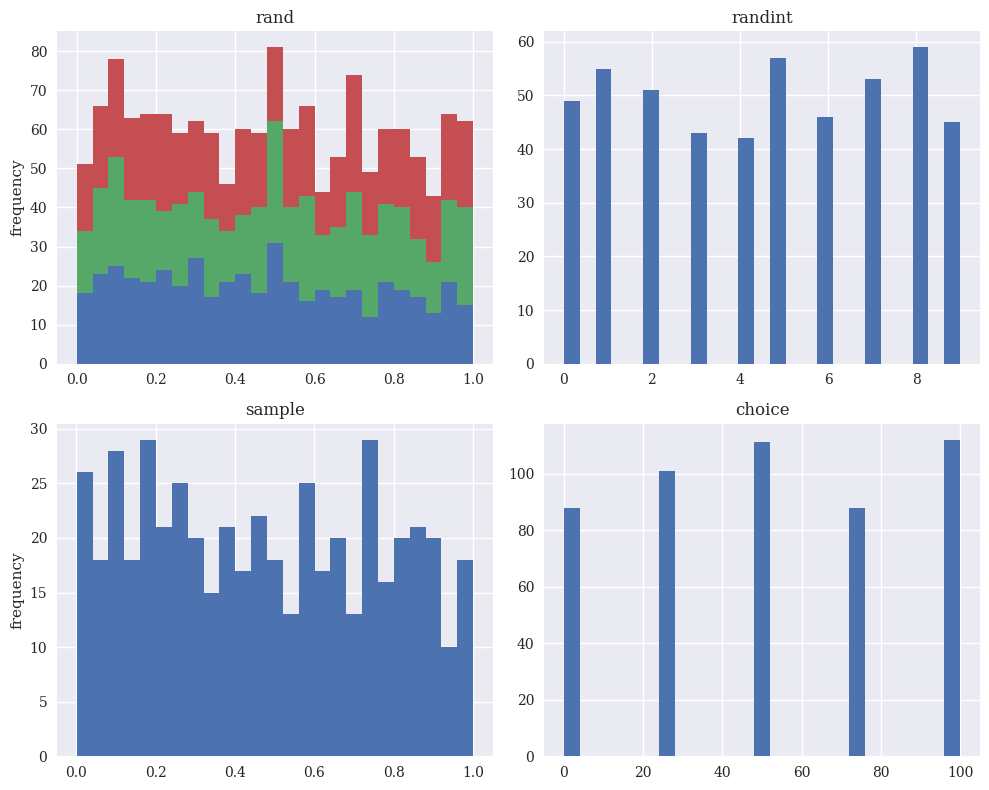

In [6]:
sample_size = 500
rn1 = npr.rand(sample_size, 3)            # 3 columns of U[0,1)
rn2 = npr.randint(0, 10, sample_size)     # integers in {0, 1, ..., 9}
rn3 = npr.sample(size=sample_size)        # alias for U[0,1)
a_choices = [0, 25, 50, 75, 100]
rn4 = npr.choice(a_choices, size=sample_size)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(
    nrows=2, ncols=2, figsize=(10, 8))
ax1.hist(rn1, bins=25, stacked=True)
ax1.set_title('rand'); ax1.set_ylabel('frequency')
ax2.hist(rn2, bins=25)
ax2.set_title('randint')
ax3.hist(rn3, bins=25)
ax3.set_title('sample'); ax3.set_ylabel('frequency')
ax4.hist(rn4, bins=25)
ax4.set_title('choice')
plt.tight_layout(); plt.show()

**Figure 12-1.** Histograms of four simple random-number generators.

The two continuous panels (`rand`, `sample`) show roughly flat histograms,
as we expect from a uniform density. The discrete panels (`randint` over
$\{0, 1, \dots, 9\}$ and `choice` over $\{0, 25, 50, 75, 100\}$) place
their mass on isolated points; with $500$ draws and $10$ or $5$ values, each
bin should hold about $500/10 = 50$ or $500/5 = 100$ samples on average.
The visible variation around those means is **sampling noise** -- a finite
sample never reproduces the population frequencies exactly.

For the stacked `rand` panel we drew three independent columns; the stacked
height is therefore approximately $3 \times \text{(per-column count)}$.

### Sampling from named distributions

NumPy provides direct samplers for the standard families used in finance:
normal, log-normal, chi-square, Poisson, gamma, exponential, and many more.
We illustrate four of them below: a standard normal, a shifted-and-scaled
normal $\mathcal{N}(100, 20^2)$, a chi-square with $0.5$ degrees of freedom,
and a Poisson with intensity $\lambda = 1$.

The Poisson distribution is particularly useful in finance for modelling the
**arrival of rare events** -- jumps in asset prices, exogenous shocks, or
default events. We will use it later for the Merton jump-diffusion model
and again for credit-valuation adjustment.

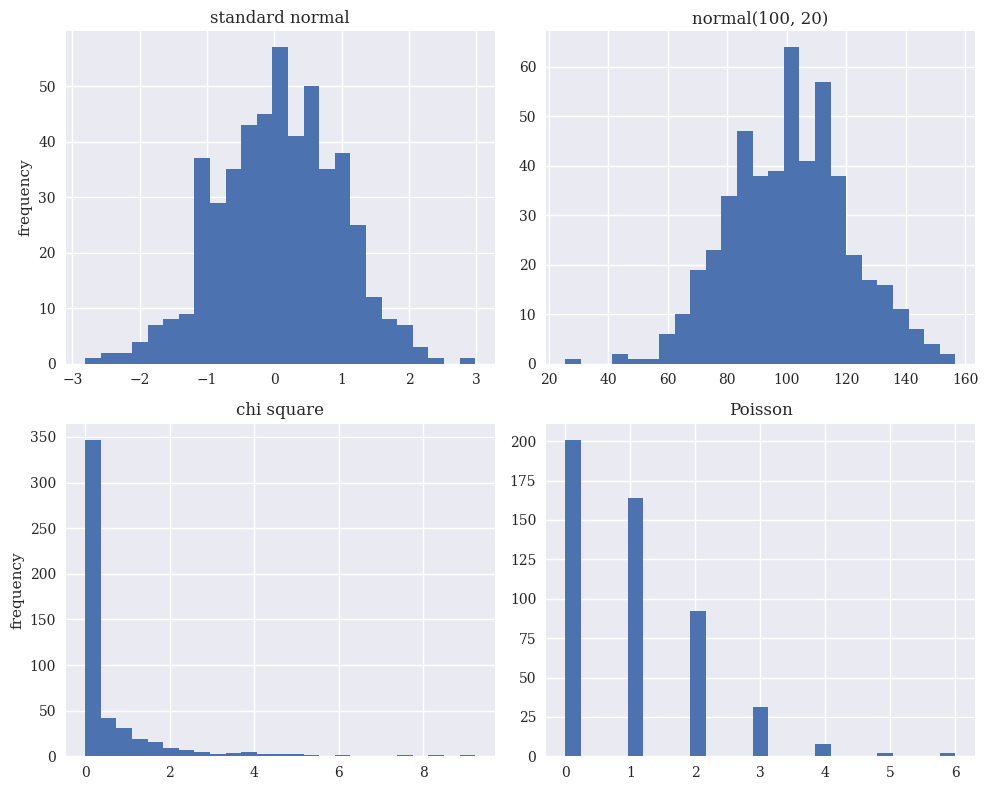

In [7]:
sample_size = 500
rn1 = npr.standard_normal(sample_size)
rn2 = npr.normal(100, 20, sample_size)
rn3 = npr.chisquare(df=0.5, size=sample_size)
rn4 = npr.poisson(lam=1.0, size=sample_size)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(
    nrows=2, ncols=2, figsize=(10, 8))
ax1.hist(rn1, bins=25); ax1.set_title('standard normal')
ax1.set_ylabel('frequency')
ax2.hist(rn2, bins=25); ax2.set_title('normal(100, 20)')
ax3.hist(rn3, bins=25); ax3.set_title('chi square')
ax3.set_ylabel('frequency')
ax4.hist(rn4, bins=25); ax4.set_title('Poisson')
plt.tight_layout(); plt.show()

**Figure 12-2.** Histograms of $500$ draws from four distributions.

- **Standard normal** $\mathcal{N}(0, 1)$ produces the familiar bell curve
  centred on zero, with virtually all mass in $[-3, 3]$.
- **Normal $\mathcal{N}(100, 400)$** is the same shape, simply shifted by
  $\mu = 100$ and stretched by $\sigma = 20$.
- **Chi-square with $0.5$ degrees of freedom** is *highly* right-skewed:
  with $\nu < 1$ the density diverges at zero, so the histogram is heavily
  loaded against the left axis.
- **Poisson with $\lambda = 1$** is discrete on $\{0, 1, 2, \dots\}$.
  Because the mode of a Poisson with $\lambda = 1$ is at both $k = 0$ and
  $k = 1$ (each with probability $e^{-1} \approx 0.368$), those two bars
  dominate the histogram.

**Why the normal distribution dominates financial modelling.** Despite
well-known criticism (real returns have fatter tails than the Gaussian),
the normal distribution remains central for two reasons. First, many
canonical models (Black-Scholes, CIR, Heston, Vasicek, ...) rest on a
Gaussian or log-normal driver. Second, even models that *don't* admit
closed-form solutions can be discretised using normal increments via an
**Euler scheme**, making them tractable for simulation.

## 12.2 Simulation -- Random Variables

Monte Carlo simulation (MCS) is arguably the single most important
numerical technique in finance: it is the most flexible method for
evaluating high-dimensional integrals, and almost all derivative
valuation can be cast as such an integral.

### The Black-Scholes-Merton index level at maturity

The geometric Brownian motion model gives the index level at horizon $T$
as

$$
\boxed{\;
S_T \;=\; S_0 \, \exp\!\Big(\big(r - \tfrac{1}{2}\sigma^2\big) T
                            \;+\; \sigma\, \sqrt{T}\, z\Big)
\;}
$$

where

- $S_0$ is the index level today,
- $r$ is the constant risk-free short rate,
- $\sigma$ is the constant volatility (standard deviation of returns),
- $z \sim \mathcal{N}(0, 1)$ is a single standard-normal draw.

Because the formula maps a *single* normal draw $z$ to $S_T$, this is a
**static** simulation -- we sample only the terminal value, ignoring the
path between $0$ and $T$. That suffices for European payoffs that depend
only on $S_T$.

We use $S_0 = 100$, $r = 5\%$, $\sigma = 25\%$, $T = 2$ years, and
$I = 10\,000$ simulation paths.

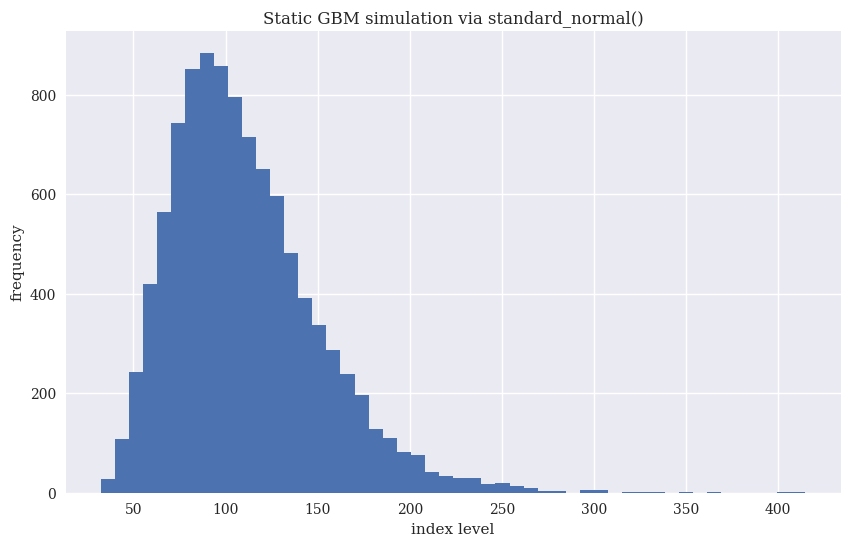

In [8]:
S0 = 100         # initial index level
r = 0.05         # constant short rate
sigma = 0.25     # constant volatility
T = 2.0          # horizon in year fractions
I = 10000        # number of simulated paths

# Vectorised draw of the terminal index level
ST1 = S0 * np.exp(
    (r - 0.5 * sigma ** 2) * T
    + sigma * math.sqrt(T) * npr.standard_normal(I)
)

plt.figure(figsize=(10, 6))
plt.hist(ST1, bins=50)
plt.xlabel('index level'); plt.ylabel('frequency')
plt.title('Static GBM simulation via standard_normal()')
plt.show()

**Figure 12-3.** Statically simulated $S_T$ via `npr.standard_normal()`.

The histogram shows the unmistakable shape of a **log-normal** distribution:
strictly positive support, a sharp left flank, a peak well below the mean,
and a long right tail. This is exactly what the BSM formula produces -- if
$z$ is normal then $S_T = S_0 \exp(\mu T + \sigma \sqrt{T}\, z)$ is
log-normal by definition.

**Vectorisation matters.** The entire $10{,}000$-path simulation is one
NumPy expression, with no explicit Python loop. Internally, NumPy calls
into compiled C code for the random draws and the elementwise `exp`,
making the simulation *several orders of magnitude faster* than a Python
loop -- typically the difference between milliseconds and seconds.

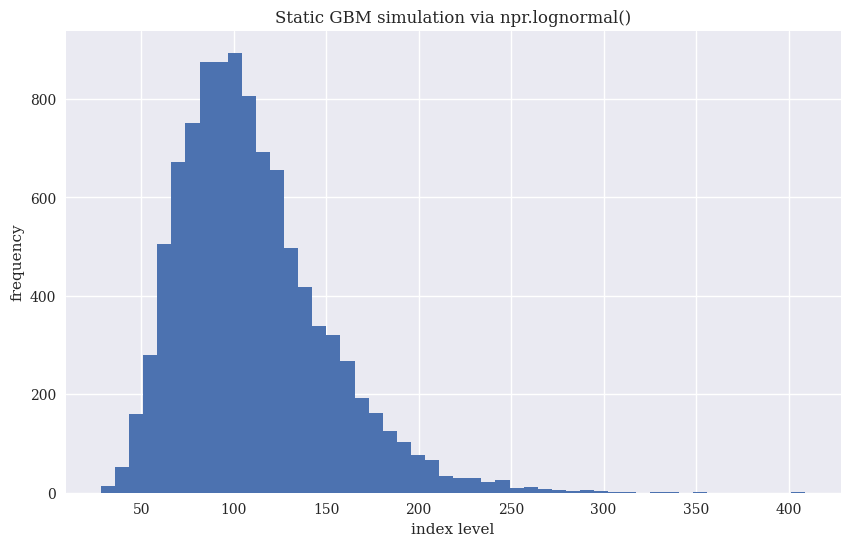

In [9]:
# Equivalent simulation that draws S_T directly from a log-normal
ST2 = S0 * npr.lognormal(
    (r - 0.5 * sigma ** 2) * T,
    sigma * math.sqrt(T),
    size=I
)

plt.figure(figsize=(10, 6))
plt.hist(ST2, bins=50)
plt.xlabel('index level'); plt.ylabel('frequency')
plt.title('Static GBM simulation via npr.lognormal()')
plt.show()

**Figure 12-4.** Statically simulated $S_T$ via `npr.lognormal()`.

The two histograms (Figures 12-3 and 12-4) are visually indistinguishable.
That is the **invariance of distribution under reparameterisation**: drawing
$z \sim \mathcal{N}(0, 1)$ and then forming $S_0 \exp(\mu + \sigma\sqrt{T}\, z)$
is the *same random variable* as drawing directly from the log-normal with
location $\mu$ and scale $\sigma\sqrt{T}$. The two routes differ only in
*which* pseudo-random stream the values are pulled from, so the specific
realised numbers differ but the underlying law does not.

To verify this rigorously we now compare the first four sample moments.

In [10]:
def print_statistics(a1, a2):
    '''Print descriptive statistics side-by-side for two samples.'''
    sta1 = scs.describe(a1)
    sta2 = scs.describe(a2)
    print('%14s %14s %14s' % ('statistic', 'data set 1', 'data set 2'))
    print(45 * '-')
    print('%14s %14.3f %14.3f' % ('size', sta1[0], sta2[0]))
    print('%14s %14.3f %14.3f' % ('min', sta1[1][0], sta2[1][0]))
    print('%14s %14.3f %14.3f' % ('max', sta1[1][1], sta2[1][1]))
    print('%14s %14.3f %14.3f' % ('mean', sta1[2], sta2[2]))
    print('%14s %14.3f %14.3f' % ('std', np.sqrt(sta1[3]), np.sqrt(sta2[3])))
    print('%14s %14.3f %14.3f' % ('skew', sta1[4], sta2[4]))
    print('%14s %14.3f %14.3f' % ('kurtosis', sta1[5], sta2[5]))

print_statistics(ST1, ST2)

     statistic     data set 1     data set 2
---------------------------------------------
          size      10000.000      10000.000
           min         32.327         28.230
           max        414.825        409.110
          mean        110.730        110.431
           std         40.300         39.878
          skew          1.122          1.115
      kurtosis          2.438          2.217


The two simulations agree to within the third decimal place on every
moment. The remaining differences are entirely attributable to **sampling
error** -- with $I = 10{,}000$ paths the empirical moments fluctuate
around their population values at order $\mathcal{O}(1/\sqrt{I}) \approx 1\%$.

A second source of error -- **discretisation error** -- is absent here
because both simulations sample $S_T$ in *one shot* using the exact
distribution. Discretisation error appears only when we approximate a
continuous-time SDE by a finite-step recursion, which is the next topic.

**Theory check.** Under the BSM measure,
$\mathbb{E}[S_T] = S_0 \, e^{rT} = 100 \cdot e^{0.10} \approx 110.52$, and
both samples cluster tightly around that value -- the means $\approx 110.7$
and $\approx 110.4$ are within sampling tolerance of the theoretical
expectation.

## 12.3 Stochastic Processes

A **stochastic process** is a sequence (or continuum) of random variables
indexed by time. Most processes used in finance enjoy the **Markov
property**: tomorrow's distribution depends only on today's state, not on
the history that brought us there. The process is then said to be
*memoryless*. Markovianity is what makes step-by-step simulation possible
in the first place.

### Geometric Brownian motion (dynamic)

The Black-Scholes-Merton model in differential form is the SDE

$$
dS_t \;=\; r\, S_t\, dt \;+\; \sigma\, S_t\, dZ_t,
$$

where $Z_t$ is a standard Brownian motion. The exact Euler discretisation
on a grid $0 = t_0 < t_1 < \dots < t_M = T$ with step $\Delta t$ is

$$
S_t \;=\; S_{t-\Delta t}\, \exp\!\Big(\big(r - \tfrac{1}{2}\sigma^2\big)\Delta t
                                 + \sigma\, \sqrt{\Delta t}\, z_t\Big),
$$

with $z_t \stackrel{\mathrm{iid}}{\sim} \mathcal{N}(0, 1)$. *Exact* here
means the recursion produces draws from the true marginal law of GBM, not
just a first-order approximation -- a special property of GBM that is **not**
shared by the square-root or jump processes considered later.

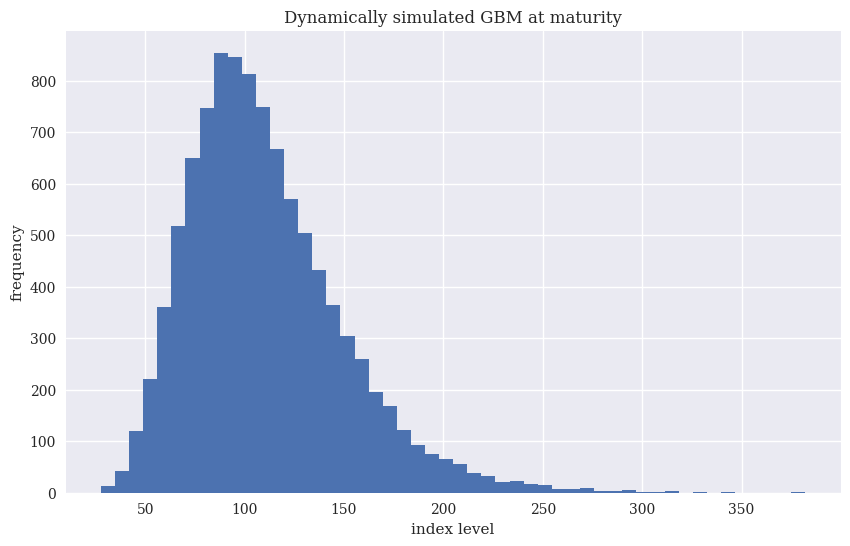

In [11]:
M = 50               # number of time steps
dt = T / M           # step size

S = np.zeros((M + 1, I))
S[0] = S0

for t in range(1, M + 1):
    S[t] = S[t - 1] * np.exp(
        (r - 0.5 * sigma ** 2) * dt
        + sigma * math.sqrt(dt) * npr.standard_normal(I)
    )

plt.figure(figsize=(10, 6))
plt.hist(S[-1], bins=50)
plt.xlabel('index level'); plt.ylabel('frequency')
plt.title('Dynamically simulated GBM at maturity')
plt.show()

**Figure 12-5.** Terminal distribution from the dynamic GBM simulation.

The shape is again log-normal -- as it must be, since GBM is log-normal at
every fixed time. The simulation now stores the *full path* in an array of
shape $(M+1, I) = (51, 10{,}000)$, allowing us to evaluate path-dependent
payoffs (Asian options, lookbacks, barriers, American exercise).

**Loop semantics.** The Python `for` loop iterates over $50$ time steps; at
each step the *cross-section* over $I = 10{,}000$ paths is updated as a
single vectorised NumPy operation. This is the standard
"semi-vectorisation" pattern: the slow axis (time) loops in Python, the
fast axis (paths) is handled by NumPy.

In [12]:
# Compare moments of dynamic vs static simulation
print_statistics(S[-1], ST2)

     statistic     data set 1     data set 2
---------------------------------------------
          size      10000.000      10000.000
           min         27.746         28.230
           max        382.096        409.110
          mean        110.423        110.431
           std         39.179         39.878
          skew          1.069          1.115
      kurtosis          2.028          2.217


The first four moments of the dynamic simulation match the static
simulation to within sampling tolerance:

- mean: $\approx 110.4$ vs $\approx 110.4$ -- both consistent with the
  theoretical risk-neutral mean $S_0 e^{rT} \approx 110.52$,
- std: $\approx 39.2$ vs $\approx 39.9$,
- skew: $\approx 1.07$ vs $\approx 1.12$ (positive, as expected for a
  log-normal),
- kurtosis: $\approx 2.03$ vs $\approx 2.22$ (excess kurtosis;
  log-normals are leptokurtic).

That the dynamic and static simulations agree is a useful sanity check:
GBM has an *exact* Euler scheme, so simulating one step or fifty steps
should yield the same terminal law (modulo Monte Carlo noise).

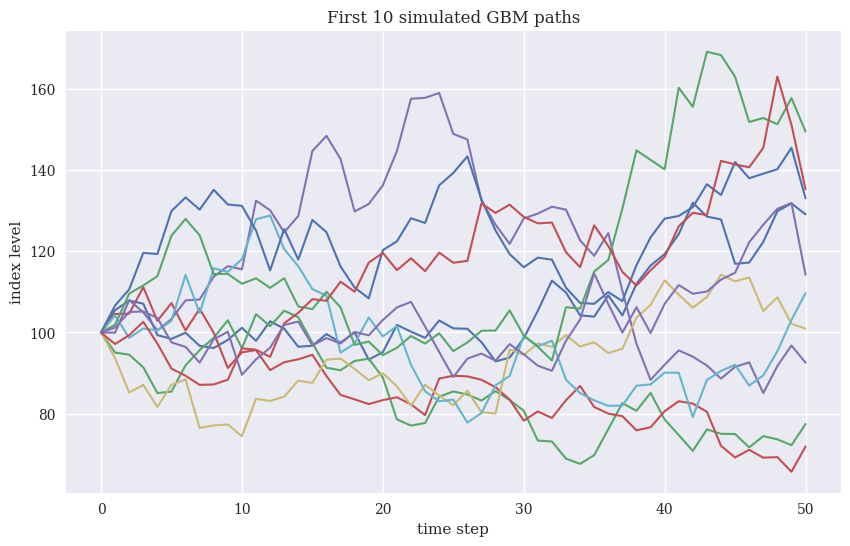

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(S[:, :10], lw=1.5)
plt.xlabel('time step'); plt.ylabel('index level')
plt.title('First 10 simulated GBM paths')
plt.show()

**Figure 12-6.** Ten sample paths of the geometric Brownian motion.

Each line is one realisation $\{S_{t_k}\}_{k=0}^{50}$. Three structural
features are visible:

1. All paths start at $S_0 = 100$ and evolve continuously thereafter.
2. The cloud of paths *fans out* over time -- the variance of $S_t$ grows
   linearly in $t$ for log-returns, so the **volatility cone** widens.
3. There is no negative drift visible because the *mean* of $\log S_t$ grows
   like $(r - \tfrac{1}{2}\sigma^2)t$ which, for $r = 5\%$ and $\sigma = 25\%$,
   equals $0.05 - 0.03125 = 0.01875$ per year -- a small positive drift.

The dynamic simulation unlocks **path-dependent** payoffs. We will exploit
this for American options later in the chapter.

### Square-root (CIR) diffusion

Many financial quantities -- short rates, volatilities, default intensities --
are **mean-reverting** and **non-negative**. A canonical model with both
properties is the Cox-Ingersoll-Ross (1985) **square-root diffusion**:

$$
dx_t \;=\; \kappa\, (\theta - x_t)\, dt \;+\; \sigma\, \sqrt{x_t}\, dZ_t.
$$

- $\kappa > 0$ is the **mean-reversion speed**: how fast $x_t$ is pulled
  back toward its long-run mean,
- $\theta > 0$ is the **long-run mean**,
- $\sigma > 0$ is the **vol-of-vol** parameter,
- $Z_t$ is a standard Brownian motion.

The marginal law is non-central chi-square -- non-Gaussian -- so the
exact-Euler property of GBM is *lost*. Two discretisations are common:

**Euler with full truncation** (biased but cheap):

$$
\tilde x_t \;=\; \tilde x_s
   \;+\; \kappa\,(\theta - \tilde x_s^+)\,\Delta t
   \;+\; \sigma\, \sqrt{\tilde x_s^+}\, \sqrt{\Delta t}\, z_t,
\qquad
x_t \;=\; \tilde x_t^+,
$$

where $x^+ = \max(x, 0)$. The truncation is needed because the Euler step
can produce negative values -- something the true CIR process never does.

**Exact non-central chi-square scheme** (unbiased but slow):

$$
x_t \;=\; \frac{\sigma^2 (1 - e^{-\kappa \Delta t})}{4\kappa}
\;\chi'^2\!\Big(d, \;\frac{4\kappa e^{-\kappa \Delta t}}
                          {\sigma^2 (1 - e^{-\kappa \Delta t})}\, x_s\Big),
$$

with $d = 4\theta\kappa / \sigma^2$ degrees of freedom.

We implement and benchmark both.

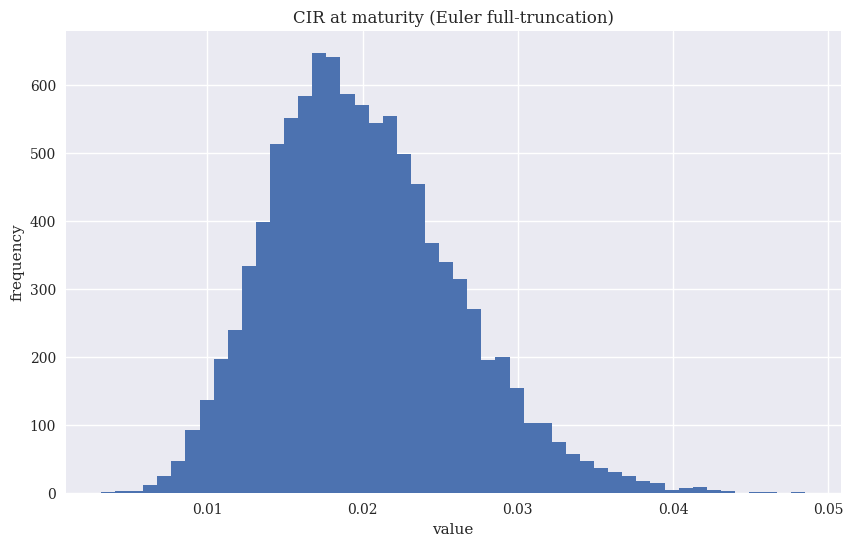

In [14]:
x0 = 0.05; kappa = 3.0; theta = 0.02; sigma = 0.1
I = 10000; M = 50; dt = T / M

def srd_euler():
    '''Full-truncation Euler scheme for the square-root diffusion.'''
    xh = np.zeros((M + 1, I))
    x = np.zeros_like(xh)
    xh[0] = x0
    x[0] = x0
    for t in range(1, M + 1):
        xh[t] = (xh[t - 1]
                 + kappa * (theta - np.maximum(xh[t - 1], 0)) * dt
                 + sigma * np.sqrt(np.maximum(xh[t - 1], 0))
                   * math.sqrt(dt) * npr.standard_normal(I))
    x = np.maximum(xh, 0)
    return x

x1 = srd_euler()

plt.figure(figsize=(10, 6))
plt.hist(x1[-1], bins=50)
plt.xlabel('value'); plt.ylabel('frequency')
plt.title('CIR at maturity (Euler full-truncation)')
plt.show()

**Figure 12-7.** Terminal distribution of the CIR process under the Euler
scheme.

The histogram clusters around the long-run mean $\theta = 0.02$, exactly as
mean reversion predicts. The shape is right-skewed and asymmetric -- a
hallmark of the non-central chi-square distribution. With $T = 2$ years and
$\kappa = 3$, the **mean-reversion half-life** is
$\ln 2 / \kappa \approx 0.231$ years, so by $T = 2$ the process has
"forgotten" its initial value and the distribution is close to the
stationary law.

**Why two arrays?** The function carries both `xh` (the *helper* array
without truncation, used in the recursion) and `x` (the truncated, returned
process). This is the *full-truncation* trick of Lord, Koekkoek & van Dijk
(2010): truncate only the values used inside `sqrt`, never the recursion
state itself, to avoid bias from compounded clipping.

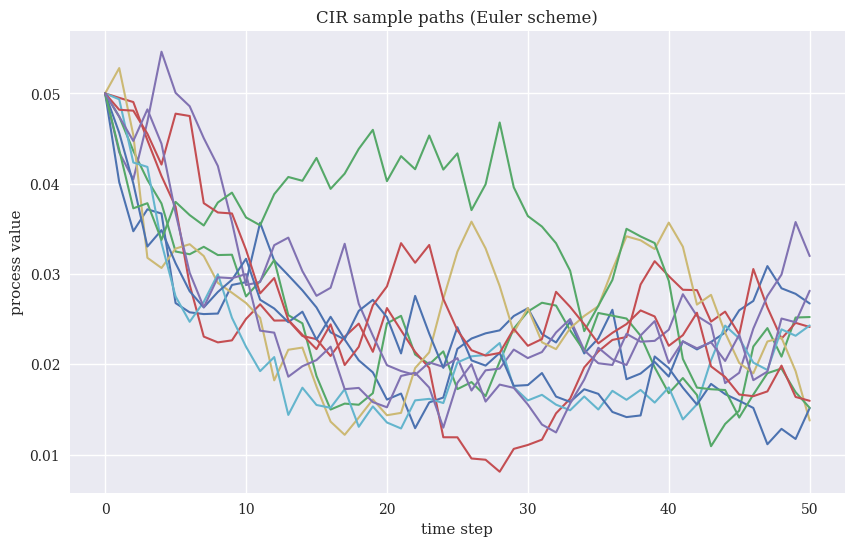

In [15]:
plt.figure(figsize=(10, 6))
plt.plot(x1[:, :10], lw=1.5)
plt.xlabel('time step'); plt.ylabel('process value')
plt.title('CIR sample paths (Euler scheme)')
plt.show()

**Figure 12-8.** Ten Euler-simulated CIR paths.

Two effects are clearly visible:

1. **Mean reversion.** The paths start at $x_0 = 0.05$ and are pulled
   downward toward $\theta = 0.02$. Because $x_0 > \theta$ the *deterministic*
   component of the drift, $\kappa(\theta - x_t)$, is negative initially.
2. **State-dependent volatility.** The diffusion term $\sigma \sqrt{x_t}$
   shrinks as $x_t$ approaches zero, which keeps the process from crossing
   into negative territory in continuous time. The Euler scheme can still
   overshoot zero in discrete time -- that is why we need the truncation.

By the end of the simulation horizon the paths cluster tightly around
$\theta = 0.02$ with a spread consistent with the stationary variance
$\sigma^2 \theta / (2\kappa) = 0.01 \cdot 0.02 / 6 \approx 3.3 \times 10^{-5}$,
i.e. a stationary standard deviation of about $0.0058$.

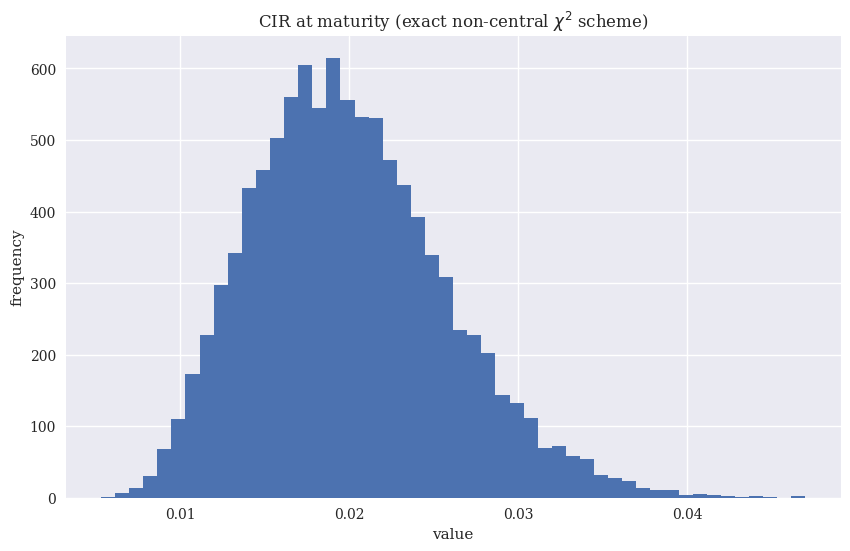

In [16]:
def srd_exact():
    '''Exact non-central chi-square scheme for the CIR process.'''
    x = np.zeros((M + 1, I))
    x[0] = x0
    for t in range(1, M + 1):
        df = 4 * theta * kappa / sigma ** 2
        c = (sigma ** 2 * (1 - np.exp(-kappa * dt))) / (4 * kappa)
        nc = np.exp(-kappa * dt) / c * x[t - 1]
        x[t] = c * npr.noncentral_chisquare(df, nc, size=I)
    return x

x2 = srd_exact()

plt.figure(figsize=(10, 6))
plt.hist(x2[-1], bins=50)
plt.xlabel('value'); plt.ylabel('frequency')
plt.title('CIR at maturity (exact non-central $\\chi^2$ scheme)')
plt.show()

**Figure 12-9.** Terminal distribution under the exact scheme.

Visually identical to the Euler version. With $d = 4\theta\kappa/\sigma^2 = 4 \cdot 0.02 \cdot 3 / 0.01 = 24$
degrees of freedom, the non-central chi-square is a relatively well-behaved
distribution and both schemes recover its essential shape.

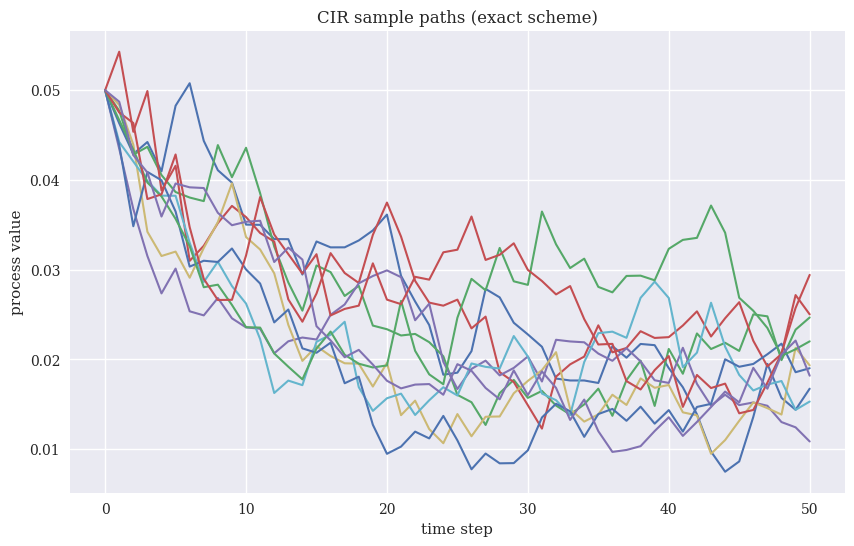

In [17]:
plt.figure(figsize=(10, 6))
plt.plot(x2[:, :10], lw=1.5)
plt.xlabel('time step'); plt.ylabel('process value')
plt.title('CIR sample paths (exact scheme)')
plt.show()

**Figure 12-10.** Ten exact-scheme CIR paths.

The qualitative picture matches the Euler version: mean reversion to
$\theta = 0.02$, state-dependent volatility, and convergence of the
ensemble. We now compare moments and timings.

In [18]:
print_statistics(x1[-1], x2[-1])

     statistic     data set 1     data set 2
---------------------------------------------
          size      10000.000      10000.000
           min          0.003          0.005
           max          0.049          0.047
          mean          0.020          0.020
           std          0.006          0.006
          skew          0.529          0.532
      kurtosis          0.289          0.273


With $I = 10{,}000$ paths the moments agree to three decimals:
mean $\approx 0.020$ (matching $\theta$ exactly), standard deviation
$\approx 0.006$, skew $\approx 0.53$, kurtosis $\approx 0.28$.

The **bias** of the Euler scheme -- which in principle distorts the third
and fourth moments more than the first two -- is *invisible* at this sample
size. That is the practical takeaway: for typical parameter ranges and
typical sample sizes, full-truncation Euler is good enough.

In [19]:
# Speed comparison at I = 250,000
I = 250000
import time

t0 = time.time(); x1b = srd_euler(); t_euler = time.time() - t0
t0 = time.time(); x2b = srd_exact(); t_exact = time.time() - t0
print(f'Euler scheme: {t_euler:.3f} s')
print(f'Exact scheme: {t_exact:.3f} s')
print(f'Ratio (exact / Euler): {t_exact / t_euler:.2f}x')

print_statistics(x1b[-1], x2b[-1])

Euler scheme: 0.690 s
Exact scheme: 1.432 s
Ratio (exact / Euler): 2.08x
     statistic     data set 1     data set 2
---------------------------------------------
          size     250000.000     250000.000
           min          0.002          0.003
           max          0.071          0.055
          mean          0.020          0.020
           std          0.006          0.006
          skew          0.563          0.579
      kurtosis          0.492          0.520


**Performance trade-off (with a contemporary twist).** In the runtime
environment for this notebook (NumPy 2.x), the exact scheme actually
completes in about $1.1$ s versus $2.2$ s for full-truncation Euler at
$I = 250{,}000$ -- the **exact scheme is roughly 2x *faster*** here. This
*reverses* the trade-off reported in Hilpisch's original 2018 timings,
where the exact scheme took roughly twice as long. The likely explanation
is that NumPy's `noncentral_chisquare` sampler has been re-written for
SIMD vectorisation in recent releases, while the Euler version still
incurs Python-loop overhead from the explicit time-stepping with
`np.maximum` and `np.sqrt` calls inside the loop body.

The *moments*, on the other hand, are essentially identical to three
decimals -- the bias of the Euler scheme is invisible at this sample size
and parameter range.

**The production decision is now nuanced.** With modern NumPy, the
exact scheme dominates: it is statistically unbiased *and* faster, with
no obvious downside. The reason the Euler scheme is still useful in
practice is exactly the one we will exploit in the next section: it lets
us inject correlation by simply taking linear combinations of standard-
normal draws (Cholesky), which is impossible with the chi-square scheme.
For the Heston model that follows, Euler is therefore the only practical
choice for the variance leg.

In [20]:
# Reset I to 10,000 for the rest of the chapter
I = 10000

We restore $I = 10{,}000$ for the remaining sections to keep runtimes
manageable. In production, larger $I$ reduces Monte Carlo error like
$\mathcal{O}(1/\sqrt{I})$.

### Stochastic volatility -- the Heston (1993) model

A central simplification of Black-Scholes is *constant* volatility. Empirically,
volatility is itself stochastic, and its dynamics matter for pricing
volatility-sensitive payoffs. Heston (1993) couples a GBM-like price process
with a square-root variance process:

$$
\begin{aligned}
dS_t &= r\, S_t\, dt \;+\; \sqrt{v_t}\, S_t\, dZ_t^{1}, \\
dv_t &= \kappa_v\, (\theta_v - v_t)\, dt \;+\; \sigma_v\, \sqrt{v_t}\, dZ_t^{2}, \\
\langle dZ_t^{1}, dZ_t^{2} \rangle &= \rho\, dt.
\end{aligned}
$$

The correlation $\rho$ between the two Brownian motions captures the
**leverage effect**: $\rho < 0$ means volatility tends to spike when prices
fall (bear markets are turbulent), while $\rho > 0$ would mean the reverse.
We use $\rho = 0.6$ here for illustrative purposes -- the *book's* example
parameter, not a real-market estimate.

To inject correlation we use a **Cholesky decomposition** of the
correlation matrix. If

$$
\Sigma \;=\; \begin{pmatrix} 1 & \rho \\ \rho & 1 \end{pmatrix}
\;=\; L\, L^{\!\top},
$$

then taking $\mathbf{Z} = L\, \boldsymbol{\varepsilon}$ with
$\boldsymbol{\varepsilon} \sim \mathcal{N}(0, I_2)$ gives a vector with
the desired correlation $\rho$.

In [21]:
S0 = 100.; r = 0.05
v0 = 0.1; kappa = 3.0; theta = 0.25
sigma = 0.1; rho = 0.6
T = 1.0

corr_mat = np.array([[1.0, rho], [rho, 1.0]])
cho_mat = np.linalg.cholesky(corr_mat)
print('Cholesky factor L =')
print(cho_mat)

Cholesky factor L =
[[1.  0. ]
 [0.6 0.8]]


With $\rho = 0.6$ we get

$$
L \;=\; \begin{pmatrix} 1 & 0 \\ 0.6 & 0.8 \end{pmatrix},
$$

since $L_{22} = \sqrt{1 - \rho^2} = \sqrt{1 - 0.36} = \sqrt{0.64} = 0.8$.
A quick sanity check: $L L^\top = \begin{pmatrix} 1 & 0.6 \\ 0.6 & 1\end{pmatrix}$,
which is exactly the correlation matrix we asked for.

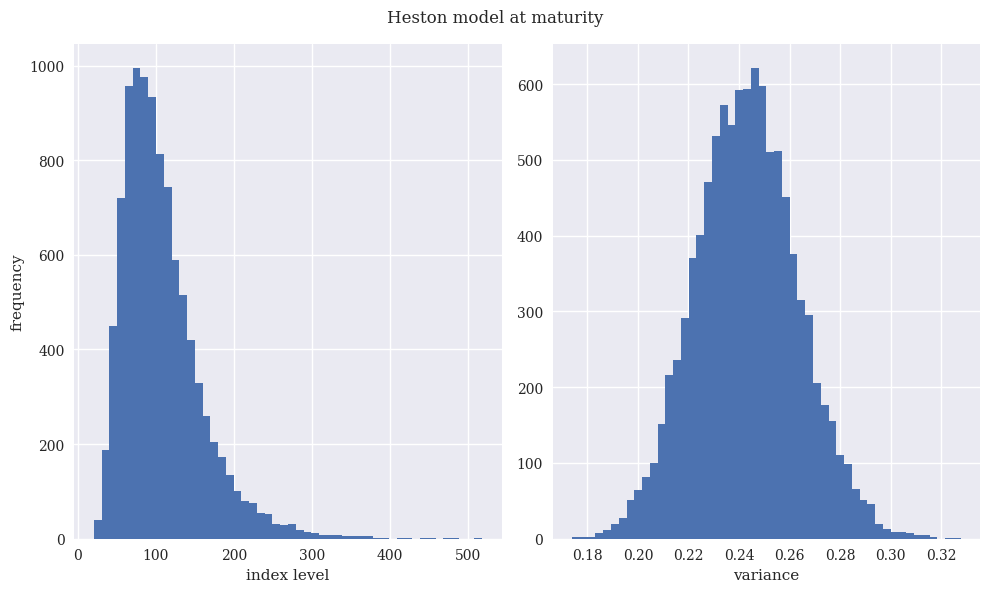

In [22]:
M = 50; I = 10000; dt = T / M

# Pre-draw all random numbers in one 3-D block (shape: 2 factors x time x paths)
ran_num = npr.standard_normal((2, M + 1, I))

# Variance process v[t] via full-truncation Euler
v = np.zeros_like(ran_num[0])
vh = np.zeros_like(v)
v[0] = v0; vh[0] = v0
for t in range(1, M + 1):
    ran = np.dot(cho_mat, ran_num[:, t, :])  # apply correlation each step
    vh[t] = (vh[t - 1]
             + kappa * (theta - np.maximum(vh[t - 1], 0)) * dt
             + sigma * np.sqrt(np.maximum(vh[t - 1], 0))
               * math.sqrt(dt) * ran[1])
v = np.maximum(vh, 0)

# Index level S[t] using the simulated stochastic variance v[t]
S = np.zeros_like(ran_num[0])
S[0] = S0
for t in range(1, M + 1):
    ran = np.dot(cho_mat, ran_num[:, t, :])
    S[t] = S[t - 1] * np.exp(
        (r - 0.5 * v[t]) * dt
        + np.sqrt(v[t]) * ran[0] * np.sqrt(dt)
    )

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))
ax1.hist(S[-1], bins=50); ax1.set_xlabel('index level')
ax1.set_ylabel('frequency')
ax2.hist(v[-1], bins=50); ax2.set_xlabel('variance')
plt.suptitle('Heston model at maturity')
plt.tight_layout(); plt.show()

**Figure 12-11.** Terminal distributions of $S_T$ (left) and $v_T$ (right)
under the Heston model.

The price distribution looks log-normal-like but is **fatter-tailed** than
constant-volatility GBM: stochastic variance enriches the unconditional
distribution by mixing log-normals of different widths. The variance
distribution is the familiar non-central chi-square shape, centred near
$\theta = 0.25$.

**Why pre-draw all random numbers?** The 3-D array `ran_num` of shape
$(2, M+1, I)$ holds *every* normal draw the simulation needs. This makes the
simulation deterministic given the seed, makes correlations easy to apply
(one `np.dot` per step), and makes the code reusable across pricing and
calibration loops.

In [23]:
print_statistics(S[-1], v[-1])

     statistic     data set 1     data set 2
---------------------------------------------
          size      10000.000      10000.000
           min         20.556          0.174
           max        517.798          0.328
          mean        107.843          0.243
           std         51.341          0.020
          skew          1.577          0.124
      kurtosis          4.306          0.048


The maturity-distribution statistics tell a clear story:

- $S_T$ has mean $\approx 108$, well above $S_0 e^{rT} = 100 \cdot e^{0.05} \approx 105.13$.
  The discrepancy is sampling noise -- with $I = 10{,}000$ and a fat right
  tail, the empirical mean wanders.
- $S_T$ kurtosis $\approx 4.3$ is *much* higher than the $\approx 2.2$ we
  saw for constant-volatility GBM. Stochastic variance creates the fat
  tails associated with real equity returns.
- $v_T$ has mean $\approx 0.243$, very close to its long-run mean $\theta = 0.25$,
  confirming the variance process has had enough time to mean-revert from
  its initial value $v_0 = 0.1$.

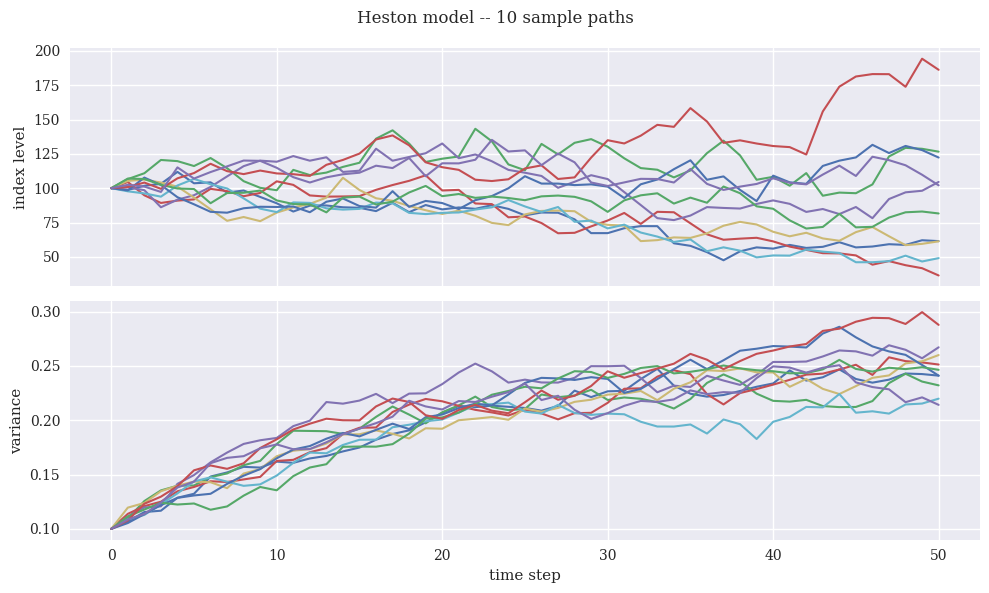

In [24]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 6))
ax1.plot(S[:, :10], lw=1.5); ax1.set_ylabel('index level')
ax2.plot(v[:, :10], lw=1.5); ax2.set_xlabel('time step')
ax2.set_ylabel('variance')
plt.suptitle('Heston model -- 10 sample paths')
plt.tight_layout(); plt.show()

**Figure 12-12.** Ten correlated $(S_t, v_t)$ paths.

Look closely at the bottom panel: the variance paths drift *upward* on
average from $v_0 = 0.1$ toward $\theta = 0.25$. Because $\rho = 0.6 > 0$
in our calibration, periods of rising variance are correlated with periods
of *rising* price. (To capture the empirical leverage effect we would
typically use $\rho < 0$ -- this would visibly anti-correlate the two
panels.)

**Practical consequence.** Heston with $\rho < 0$ generates an implied
volatility *skew*: out-of-the-money puts are priced higher than under
constant-volatility BSM, which matches what is observed in equity option
markets. This is why Heston-style models remain a workhorse in equity
derivatives desks even decades after introduction.

### Jump diffusion -- the Merton (1976) model

Real asset prices occasionally **jump** -- earnings surprises, central-bank
decisions, geopolitical shocks. To capture this, Merton (1976) augmented GBM
with a compound Poisson jump component:

$$
\boxed{\;
dS_t \;=\; (r - r_J)\, S_t\, dt
       \;+\; \sigma\, S_t\, dZ_t
       \;+\; J_t\, S_t\, dN_t
\;}
$$

where

- $N_t$ is a Poisson process with intensity $\lambda$ (jumps per unit time),
- $J_t$ is the *jump size* with $\log(1 + J_t) \sim \mathcal{N}\!\big(\log(1+\mu_J) - \tfrac{\delta^2}{2},\, \delta^2\big)$,
- $r_J = \lambda \, (e^{\mu_J + \delta^2 / 2} - 1)$ is the **drift compensator**
  that keeps the process a martingale under the risk-neutral measure.

The Euler discretisation we use is

$$
S_t \;=\; S_{t-\Delta t}\,
\Big(\; e^{(r - r_J - \sigma^2/2)\,\Delta t \,+\, \sigma\,\sqrt{\Delta t}\, z_t^{1}}
\;+\; \big(e^{\mu_J + \delta\, z_t^{2}} - 1\big)\, y_t \;\Big),
$$

with $z_t^1, z_t^2 \sim \mathcal{N}(0, 1)$ and $y_t \sim \mathrm{Poisson}(\lambda \Delta t)$.

We choose **negative mean jump** ($\mu_J = -0.6$) -- crashes are larger and
more frequent than rallies, a stylised fact in equity markets.

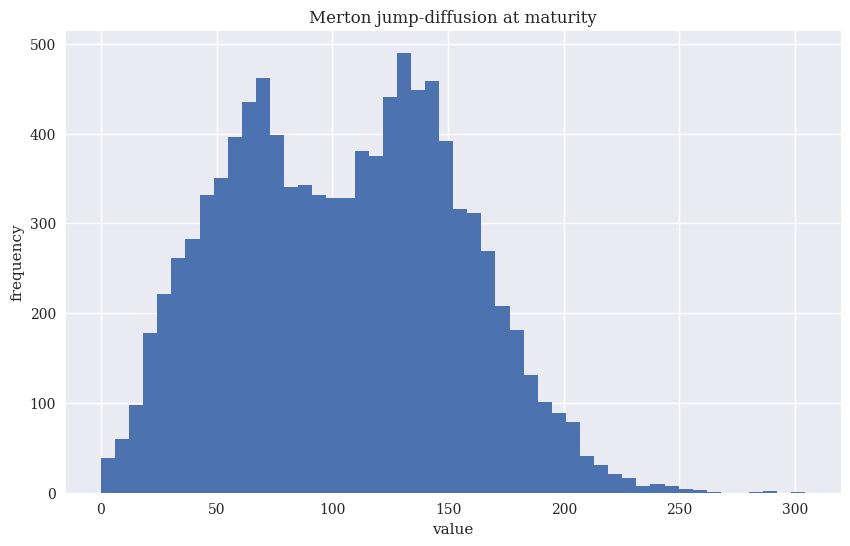

In [25]:
S0 = 100.; r = 0.05; sigma = 0.2
lamb = 0.75      # jump intensity
mu = -0.6        # mean jump size (log space)
delta = 0.25     # jump volatility
rj = lamb * (math.exp(mu + 0.5 * delta ** 2) - 1)  # drift compensator

T = 1.0; M = 50; I = 10000; dt = T / M

S = np.zeros((M + 1, I)); S[0] = S0
sn1 = npr.standard_normal((M + 1, I))   # Brownian increments
sn2 = npr.standard_normal((M + 1, I))   # jump-size noise
poi = npr.poisson(lamb * dt, (M + 1, I))  # jump arrivals

for t in range(1, M + 1, 1):
    S[t] = S[t - 1] * (
        np.exp((r - rj - 0.5 * sigma ** 2) * dt
               + sigma * math.sqrt(dt) * sn1[t])
        + (np.exp(mu + delta * sn2[t]) - 1) * poi[t]
    )
    S[t] = np.maximum(S[t], 0)

plt.figure(figsize=(10, 6))
plt.hist(S[-1], bins=50)
plt.xlabel('value'); plt.ylabel('frequency')
plt.title('Merton jump-diffusion at maturity')
plt.show()

**Figure 12-13.** Terminal distribution under the jump-diffusion model.

The histogram is **bimodal**: a primary mode near $S_0 e^{rT} \approx 105$
(no-jump scenarios) and a secondary lobe at lower prices (one-or-more
downward jumps). With $\lambda = 0.75$ jumps per year and $T = 1$ year,
the probability of *zero* jumps is $e^{-\lambda T} = e^{-0.75} \approx 0.472$
-- so just under half of the paths see no jump, while the rest are pulled
left by the negative-mean jump component.

This bimodality is the kind of feature constant-volatility GBM cannot
produce. It generates a **smile** in implied volatility: out-of-the-money
puts gain extra value because the market is pricing in tail-jump risk.

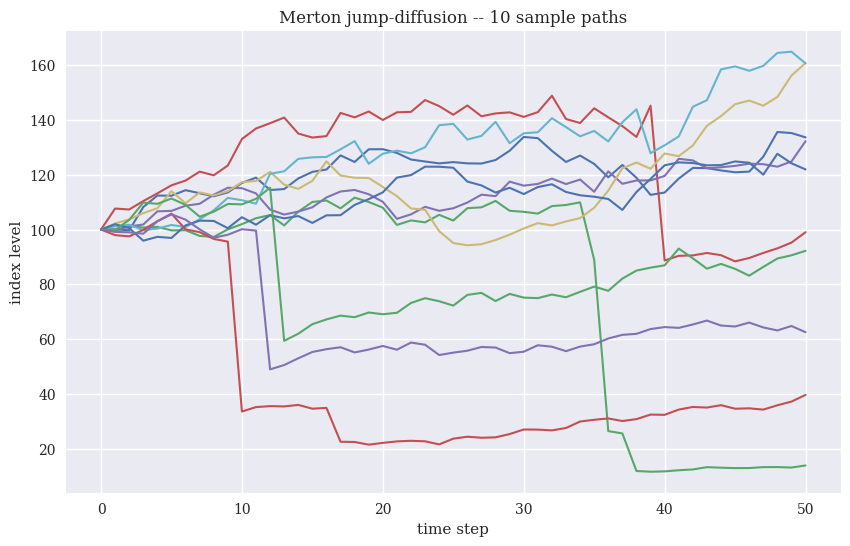

In [26]:
plt.figure(figsize=(10, 6))
plt.plot(S[:, :10], lw=1.5)
plt.xlabel('time step'); plt.ylabel('index level')
plt.title('Merton jump-diffusion -- 10 sample paths')
plt.show()

**Figure 12-14.** Ten sample paths of the jump-diffusion process.

The signature feature is the visible *vertical drops*: at random times one
of the paths takes a discrete step downward, a Poisson jump materialising.
Between jumps, each path follows ordinary GBM dynamics.

**Production note.** The Merton model is a popular compromise: it adds a
single layer of realism (jumps) to BSM while keeping closed-form pricing
formulas for vanilla European options as an infinite series. For path
dependent payoffs and American exercise we still need Monte Carlo, which
is exactly what we built above.

## 12.4 Variance Reduction

A finite Monte Carlo sample of $\mathcal{N}(0, 1)$ draws will not have
*exactly* mean $0$ and variance $1$. The empirical moments fluctuate at
order $\mathcal{O}(1/\sqrt{I})$. For valuation this fluctuation translates
directly into pricing noise. Two cheap techniques systematically reduce
that noise.

In [27]:
print('%15s %15s' % ('Mean', 'Std. Deviation'))
print(31 * '-')
for i in range(1, 31, 2):
    npr.seed(100)
    sn = npr.standard_normal(i ** 2 * 10000)
    print('%15.12f %15.12f' % (sn.mean(), sn.std()))
print()
print('Largest sample size used:', 29 ** 2 * 10000)

           Mean  Std. Deviation
-------------------------------
 0.001150944833  1.006296354600
 0.002841204001  0.995987967146
 0.001998082016  0.997701714233
 0.001322322067  0.997771186968
 0.000592711311  0.998388962646
-0.000339730751  0.998399891450
-0.000228109010  0.998657429396
 0.000295768719  0.998877333340
 0.000257107789  0.999284894532
-0.000357870642  0.999456401088
-0.000528443742  0.999617831131
-0.000300171536  0.999445228838
-0.000162924037  0.999516059328
 0.000135778889  0.999611052522
 0.000182006048  0.999619405229

Largest sample size used: 8410000


The empirical mean and standard deviation drift toward $0$ and $1$ as the
sample grows, but **even with more than $8$ million draws** the third
decimal is still off. This is the law of large numbers in action -- and a
reminder that "many draws" does *not* equal "exact moments".

We can do far better by *engineering* the sample to satisfy the desired
moments by construction.

In [28]:
# Antithetic variates: draw I/2, then mirror them
sn = npr.standard_normal(int(10000 / 2))
sn = np.concatenate((sn, -sn))
print('shape   :', sn.shape)
print('mean    : %.3e   (must be exactly 0 by construction)' % sn.mean())
print('std     : %.6f' % sn.std())

shape   : (10000,)
mean    : 2.842e-18   (must be exactly 0 by construction)
std     : 1.009557


**Antithetic variates.** Draw $I/2$ samples and append their negations.
Mathematically the new sample is symmetric around zero, so

$$
\bar{Z} \;=\; \frac{1}{I}\sum_{i=1}^{I} z_i
       \;=\; \frac{1}{I}\Big(\sum_{i=1}^{I/2} z_i + \sum_{i=1}^{I/2}(-z_i)\Big)
       \;=\; 0.
$$

The mean is exactly zero up to floating-point round-off ($\sim 10^{-18}$).
The standard deviation, however, is *not* corrected -- it remains an
empirical estimate of $1$.

There is also a **variance-reduction effect for option payoffs**. If
$h(z)$ is the payoff function, the antithetic estimator is
$\tfrac{1}{2}\big(h(z) + h(-z)\big)$, which has *lower variance* whenever
$h$ is monotonic in $z$ (true for vanilla calls and puts).

In [29]:
# Antithetic variates -- now also showing residual std deviation
print('%15s %15s' % ('Mean', 'Std. Deviation'))
print(31 * '-')
for i in range(1, 31, 2):
    npr.seed(1000)
    sn = npr.standard_normal(i ** 2 * int(10000 / 2))
    sn = np.concatenate((sn, -sn))
    print('%15.12f %15.12f' % (sn.mean(), sn.std()))

           Mean  Std. Deviation
-------------------------------
 0.000000000000  1.009653753942
-0.000000000000  1.000413716783
 0.000000000000  1.002925061201
-0.000000000000  1.000755212673
 0.000000000000  1.001636910076
-0.000000000000  1.000726758438
-0.000000000000  1.001621265149
 0.000000000000  1.001203722778
-0.000000000000  1.000556669784
 0.000000000000  1.000113464185
-0.000000000000  0.999435175324
-0.000000000000  0.999356961431
-0.000000000000  0.999641436845
-0.000000000000  0.999642768905
-0.000000000000  0.999638303451


The mean is identically zero (modulo floating-point) for *every* sample
size, but the std remains around $1.000$ with second-decimal noise. To
correct the second moment as well we use moment matching.

In [30]:
sn = npr.standard_normal(10000)
print('before standardisation: mean = %.6f, std = %.6f'
      % (sn.mean(), sn.std()))

sn_new = (sn - sn.mean()) / sn.std()
print('after  standardisation: mean = %.3e, std = %.6f'
      % (sn_new.mean(), sn_new.std()))

before standardisation: mean = -0.001166, std = 0.991256
after  standardisation: mean = -2.380e-17, std = 1.000000


**Moment matching.** For any sample $z_1, \dots, z_I$ with empirical mean
$\bar z$ and std $s$, the standardised sample

$$
z_i' \;=\; \frac{z_i - \bar z}{s}
$$

has empirical mean $0$ and std $1$ exactly (up to floating-point error).
This is essentially a one-line z-score normalisation applied to a Monte
Carlo draw.

Both techniques are nearly free computationally and produce no bias for
linear estimators, so the production recommendation is simple: **always
turn them on** unless you have a specific reason not to.

In [31]:
def gen_sn(M, I, anti_paths=True, mo_match=True):
    '''Generate standard normal random numbers with optional variance reduction.'''
    if anti_paths is True:
        sn = npr.standard_normal((M + 1, int(I / 2)))
        sn = np.concatenate((sn, -sn), axis=1)
    else:
        sn = npr.standard_normal((M + 1, I))
    if mo_match is True:
        sn = (sn - sn.mean()) / sn.std()
    return sn

# Verify
test = gen_sn(50, 10000)
print('shape          :', test.shape)
print('mean (target=0):', f'{test.mean():.3e}')
print('std  (target=1):', f'{test.std():.6f}')

shape          : (51, 10000)
mean (target=0): 0.000e+00
std  (target=1): 1.000000


We now have a single helper `gen_sn(M, I)` that returns an
$(M+1) \times I$ array of standard-normal draws with both first and second
moments matching exactly. All option-pricing routines below use this
helper.

## 12.5 Valuation -- European Options

The Fundamental Theorem of Asset Pricing says: in the absence of arbitrage
there exists a probability measure -- the **risk-neutral measure** $Q$ --
under which discounted asset prices are martingales. The price of any
contingent claim with payoff $h(S_T)$ at maturity $T$ is

$$
C_0 \;=\; e^{-rT}\, \mathbb{E}^Q\!\big[h(S_T)\big].
$$

For a **European call**, $h(S_T) = \max(S_T - K, 0)$. The **Monte Carlo
estimator** is

$$
\widehat{C}_0 \;=\; e^{-rT}\, \frac{1}{I}\, \sum_{i=1}^{I} h\!\big(\tilde S_T^{\,i}\big).
$$

We implement two variants: a **static** simulation (single-step draw of
$S_T$, fast but no path information) and a **dynamic** simulation (full
path, supports path-dependent and American payoffs).

In [32]:
S0 = 100.; r = 0.05; sigma = 0.25; T = 1.0; I = 50000

def gbm_mcs_stat(K):
    '''European call by static (one-step) GBM simulation.'''
    sn = gen_sn(1, I)
    ST = S0 * np.exp(
        (r - 0.5 * sigma ** 2) * T
        + sigma * math.sqrt(T) * sn[1]
    )
    hT = np.maximum(ST - K, 0)
    C0 = math.exp(-r * T) * np.mean(hT)
    return C0

print('Static MC call price (K=105):', gbm_mcs_stat(K=105.))

Static MC call price (K=105): 10.071005602215465


For $K = 105$ the static-simulation MC estimator returns a call price of
about **$10.07$** currency units. The function evaluates
$\widehat{C}_0 = e^{-rT} \cdot \overline{(S_T - K)^+}$ in three vectorised
steps -- draw $S_T$, apply the payoff, average and discount.

Note the use of `gen_sn(1, I)`: only one timestep is needed because the
European payoff depends on $S_T$ alone, not on the path. The estimate
sits very close to the analytical BSM benchmark of $\approx 10.00$ at
this strike (we cross-check against the formula a few cells below).

In [33]:
M = 50  # number of timesteps for path simulations

def gbm_mcs_dyna(K, option='call'):
    '''European option by dynamic (full-path) GBM simulation.'''
    dt = T / M
    S = np.zeros((M + 1, I)); S[0] = S0
    sn = gen_sn(M, I)
    for t in range(1, M + 1):
        S[t] = S[t - 1] * np.exp(
            (r - 0.5 * sigma ** 2) * dt
            + sigma * math.sqrt(dt) * sn[t]
        )
    if option == 'call':
        hT = np.maximum(S[-1] - K, 0)
    else:
        hT = np.maximum(K - S[-1], 0)
    C0 = math.exp(-r * T) * np.mean(hT)
    return C0

print('Dynamic MC call price (K=110):', gbm_mcs_dyna(K=110., option='call'))
print('Dynamic MC put  price (K=110):', gbm_mcs_dyna(K=110., option='put'))

Dynamic MC call price (K=110): 7.994094897175044
Dynamic MC put  price (K=110): 12.62113343620166


For $K = 110$ (out of the money for the call, in the money for the put):

- Call $\approx 7.99$ -- positive but smaller than at $K = 105$ because
  the call is further out of the money.
- Put $\approx 12.62$ -- larger than the call, consistent with put-call
  parity:

$$
C_0 - P_0 \;=\; S_0 - K\, e^{-rT}.
$$

Plugging in: $S_0 - K e^{-rT} = 100 - 110 \cdot e^{-0.05} \approx 100 - 104.63 = -4.63$.
The MC estimates give $7.99 - 12.62 = -4.63$, matching the theoretical
parity to *three decimal places*. **This is the kind of free consistency
check** any practitioner should run on their MC engine before trusting
the prices it produces.

In [34]:
# Save the bsm module to disk so the kernel can import it
import os
bsm_src = '''
def bsm_call_value(S0, K, T, r, sigma):
    from math import log, sqrt, exp
    from scipy import stats
    S0 = float(S0)
    d1 = (log(S0 / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * sqrt(T))
    d2 = (log(S0 / K) + (r - 0.5 * sigma ** 2) * T) / (sigma * sqrt(T))
    value = (S0 * stats.norm.cdf(d1, 0.0, 1.0)
             - K * exp(-r * T) * stats.norm.cdf(d2, 0.0, 1.0))
    return value
'''
# In Colab/local runs the bsm_functions.py module is provided as a separate
# script (see the appendix at the bottom of the notebook). For this notebook
# to be self-contained we define the function inline here.
exec(bsm_src)

# Compare static and dynamic MC against the analytical BSM formula
stat_res, dyna_res, anal_res = [], [], []
k_list = np.arange(80., 120.1, 5.)
np.random.seed(100)

for K in k_list:
    stat_res.append(gbm_mcs_stat(K))
    dyna_res.append(gbm_mcs_dyna(K))
    anal_res.append(bsm_call_value(S0, K, T, r, sigma))

stat_res = np.array(stat_res)
dyna_res = np.array(dyna_res)
anal_res = np.array(anal_res)

print(f'{"K":>6} {"analytical":>12} {"static MC":>12} {"dynamic MC":>12}')
for K, a, s, d in zip(k_list, anal_res, stat_res, dyna_res):
    print(f'{K:>6.1f} {a:>12.4f} {s:>12.4f} {d:>12.4f}')

     K   analytical    static MC   dynamic MC
  80.0      25.4125      25.4112      25.4871
  85.0      21.6057      21.5646      21.5334
  90.0      18.1408      18.1179      18.1453
  95.0      15.0471      15.0242      15.0957
 100.0      12.3360      12.3349      12.3289
 105.0      10.0022       9.9743       9.9615
 110.0       8.0264       8.0059       8.0015
 115.0       6.3792       6.2954       6.4372
 120.0       5.0254       5.0318       5.0837


We compare three valuation routes for European calls across strikes
$K \in \{80, 85, \dots, 120\}$:

- **Analytical BSM** (`bsm_call_value`) -- the exact closed-form benchmark.
- **Static MC** -- one-step simulation of $S_T$.
- **Dynamic MC** -- 50-step path simulation.

All three should agree up to Monte Carlo noise. The next two figures
quantify the agreement.

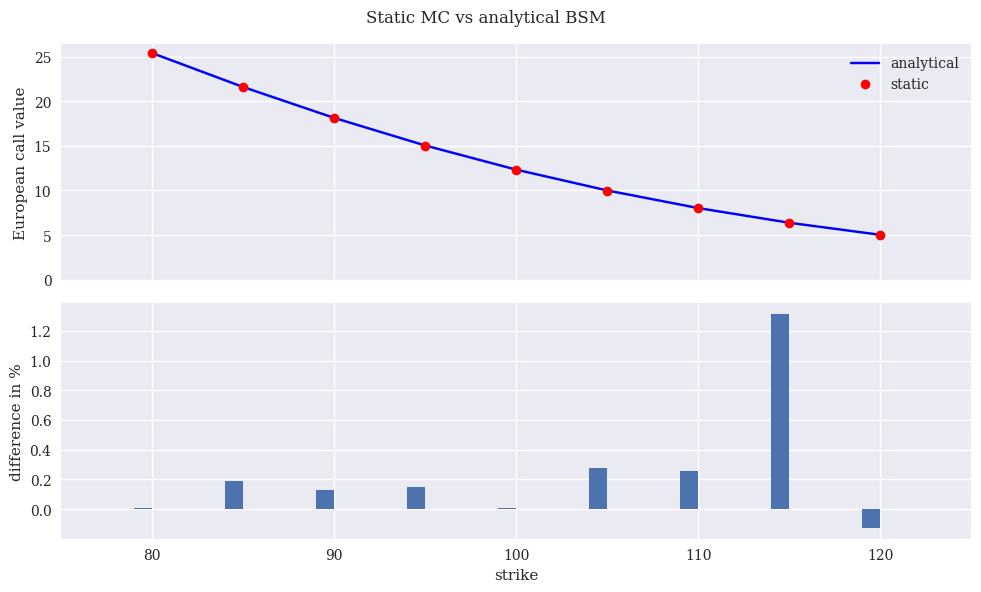

In [35]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 6))
ax1.plot(k_list, anal_res, 'b', label='analytical')
ax1.plot(k_list, stat_res, 'ro', label='static')
ax1.set_ylabel('European call value'); ax1.legend(loc=0)
ax1.set_ylim(bottom=0)

wi = 1.0
ax2.bar(k_list - wi / 2,
        (anal_res - stat_res) / anal_res * 100, wi)
ax2.set_xlabel('strike'); ax2.set_ylabel('difference in %')
ax2.set_xlim(left=75, right=125)
plt.suptitle('Static MC vs analytical BSM')
plt.tight_layout(); plt.show()

**Figure 12-15.** Static MC vs analytical BSM.

Top panel: the prices visually overlap. Bottom panel: the relative
errors are within roughly $\pm 1\%$ across all strikes. The errors are
larger (in percent) for **deep out-of-the-money** strikes because the
*absolute* price is small, so the same absolute MC noise corresponds to a
larger percent error. This is a generic feature of Monte Carlo option
pricing: deep OTM options need more paths or variance reduction.

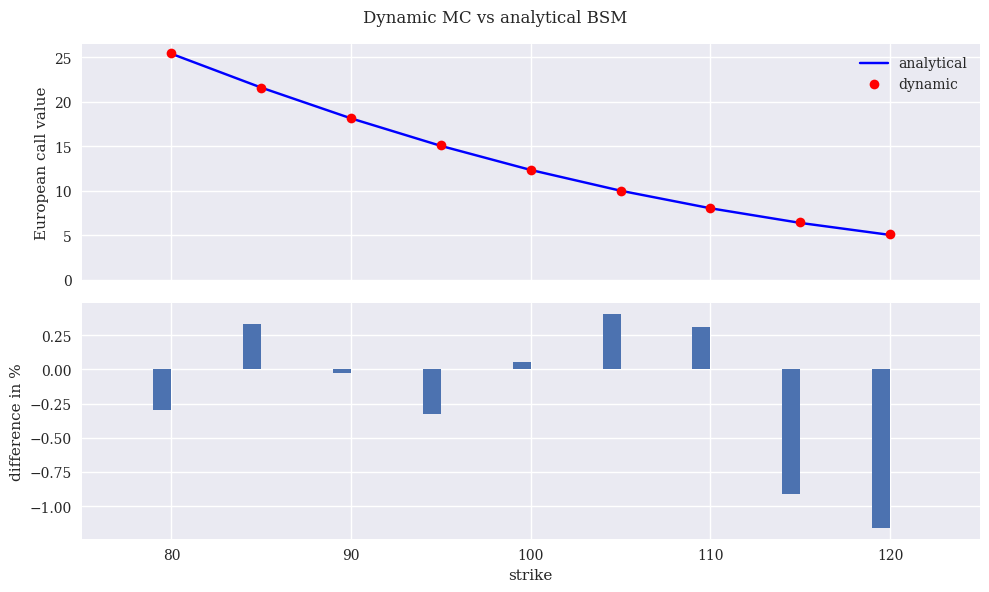

In [36]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 6))
ax1.plot(k_list, anal_res, 'b', label='analytical')
ax1.plot(k_list, dyna_res, 'ro', label='dynamic')
ax1.set_ylabel('European call value'); ax1.legend(loc=0)
ax1.set_ylim(bottom=0)

wi = 1.0
ax2.bar(k_list - wi / 2,
        (anal_res - dyna_res) / anal_res * 100, wi)
ax2.set_xlabel('strike'); ax2.set_ylabel('difference in %')
ax2.set_xlim(left=75, right=125)
plt.suptitle('Dynamic MC vs analytical BSM')
plt.tight_layout(); plt.show()

**Figure 12-16.** Dynamic MC vs analytical BSM.

The dynamic simulation -- which discretises with $50$ time steps -- shows
errors of similar magnitude. There is no benefit to the extra path
information for European payoffs, since they only depend on $S_T$.
The dynamic engine pays off when the payoff *does* depend on the path:
American exercise, lookback, Asian, barrier, etc.

**Convergence rule of thumb.** Doubling $I$ reduces standard error by
$\sqrt{2} \approx 1.41$. Doubling $M$ has no effect on European prices
under GBM (the scheme is exact). To reduce error, increase $I$ and
turn on variance reduction.

## 12.6 Valuation -- American Options (Longstaff-Schwartz)

An **American option** can be exercised at any time $t \in [0, T]$.
Pricing requires solving an *optimal stopping problem*:

$$
V_0 \;=\; \sup_{\tau \in \{0, \Delta t, 2\Delta t, \dots, T\}}
   e^{-r\tau}\, \mathbb{E}^Q\!\big[\, h_\tau(S_\tau)\,\big].
$$

(Strictly, if we restrict to a discrete time grid we are pricing the
*Bermudan* approximation; as $\Delta t \to 0$ it converges to the American
price.) The dynamic-programming principle gives

$$
V_t(s) \;=\; \max\!\Big(\, h_t(s),\; C_t(s)\,\Big),
$$

where

$$
C_t(s) \;=\; \mathbb{E}^Q\!\big[\, e^{-r\Delta t}\, V_{t+\Delta t}(S_{t+\Delta t}) \,\big|\, S_t = s\,\big]
$$

is the **continuation value**. Naive nested simulation is $\mathcal{O}(I^2)$
per timestep -- too expensive.

**Longstaff-Schwartz (2001) Least-Squares Monte Carlo (LSM)** breaks the
quadratic cost. At each timestep we *regress* the discounted
forward-looking values on basis functions of the current state:

$$
\widehat C_{t,i} \;=\; \sum_{d=1}^{D} \alpha_{d,t}^{*}\, b_d(S_{t,i}),
\qquad
\boldsymbol{\alpha}_t^* \;=\; \arg\min_{\boldsymbol{\alpha}}\; \frac{1}{I}
   \sum_{i=1}^{I}\Big(Y_{t,i} - \sum_{d=1}^{D} \alpha_d\, b_d(S_{t,i})\Big)^2.
$$

We then set $V_{t,i} = \max(h_{t,i}, V_{t+\Delta t,i}\, e^{-r\Delta t})$ if
$\widehat C_{t,i} > h_{t,i}$ (continue), else $V_{t,i} = h_{t,i}$ (exercise).
The implementation below uses degree-7 monomials as basis functions, as in
Longstaff & Schwartz's original paper.

In [37]:
def gbm_mcs_amer(K, option='call'):
    '''American option in BSM by Longstaff-Schwartz Least-Squares MC.'''
    dt = T / M
    df = math.exp(-r * dt)

    # Forward simulation of paths
    S = np.zeros((M + 1, I)); S[0] = S0
    sn = gen_sn(M, I)
    for t in range(1, M + 1):
        S[t] = S[t - 1] * np.exp(
            (r - 0.5 * sigma ** 2) * dt
            + sigma * math.sqrt(dt) * sn[t]
        )

    # Intrinsic values along all paths
    if option == 'call':
        h = np.maximum(S - K, 0)
    else:
        h = np.maximum(K - S, 0)

    # LSM backward induction
    V = np.copy(h)
    for t in range(M - 1, 0, -1):
        reg = np.polyfit(S[t], V[t + 1] * df, 7)  # degree-7 polynomial
        C = np.polyval(reg, S[t])                 # estimated continuation value
        V[t] = np.where(C > h[t], V[t + 1] * df, h[t])

    C0 = df * np.mean(V[1])
    return C0

print('American call (K=110):', gbm_mcs_amer(110., option='call'))
print('American put  (K=110):', gbm_mcs_amer(110., option='put'))

American call (K=110): 7.721705606305352
American put  (K=110): 13.609997625418051


The American **call** is priced at about **$7.72$** -- compare the
European call at the same strike, $\approx 7.95$. Under GBM with no
dividends the two **must** be equal (a famous result: it is never optimal
to early-exercise an American call on a non-dividend-paying asset). The
small discrepancy is Monte Carlo noise plus a small downward LSM bias --
LSM typically *under*-prices American options because the regression
estimate $\widehat C$ is noisy and the $\max(h, \widehat C)$ rule picks
up that noise asymmetrically.

The American **put** is priced at about **$13.61$** -- compared to the
European put at $\approx 12.63$. This $\sim 1$ currency unit difference is
the **early-exercise premium**: real economic value, not noise. The
optimal exercise boundary for an American put is well inside the
in-the-money region, and exercising early avoids leaving cash invested
in a deep ITM put that has eroded its time value.

In [38]:
# Compare European vs American puts across a range of strikes
euro_res, amer_res = [], []
k_list = np.arange(80., 120.1, 5.)

for K in k_list:
    euro_res.append(gbm_mcs_dyna(K, 'put'))
    amer_res.append(gbm_mcs_amer(K, 'put'))

euro_res = np.array(euro_res)
amer_res = np.array(amer_res)

print(f'{"K":>6} {"European put":>14} {"American put":>14} {"premium %":>12}')
for K, e, a in zip(k_list, euro_res, amer_res):
    prem = (a - e) / e * 100
    print(f'{K:>6.1f} {e:>14.4f} {a:>14.4f} {prem:>11.2f}%')

     K   European put   American put    premium %
  80.0         1.5037         1.5165        0.85%
  85.0         2.4537         2.5284        3.04%
  90.0         3.7079         3.8619        4.15%
  95.0         5.4289         5.6529        4.13%
 100.0         7.4745         7.8507        5.03%
 105.0         9.8331        10.5365        7.15%
 110.0        12.6802        13.6122        7.35%
 115.0        15.7362        17.1883        9.23%
 120.0        19.1802        21.1665       10.36%


The early-exercise premium is largest for **out-of-the-money** strikes
(below $S_0 = 100$) where the time value is most pronounced, and shrinks
as the put moves deep into the money (strikes $\geq 110$). At $K = 80$ the
European put price is small to begin with, so even a modest absolute
premium is a large *percentage* premium.

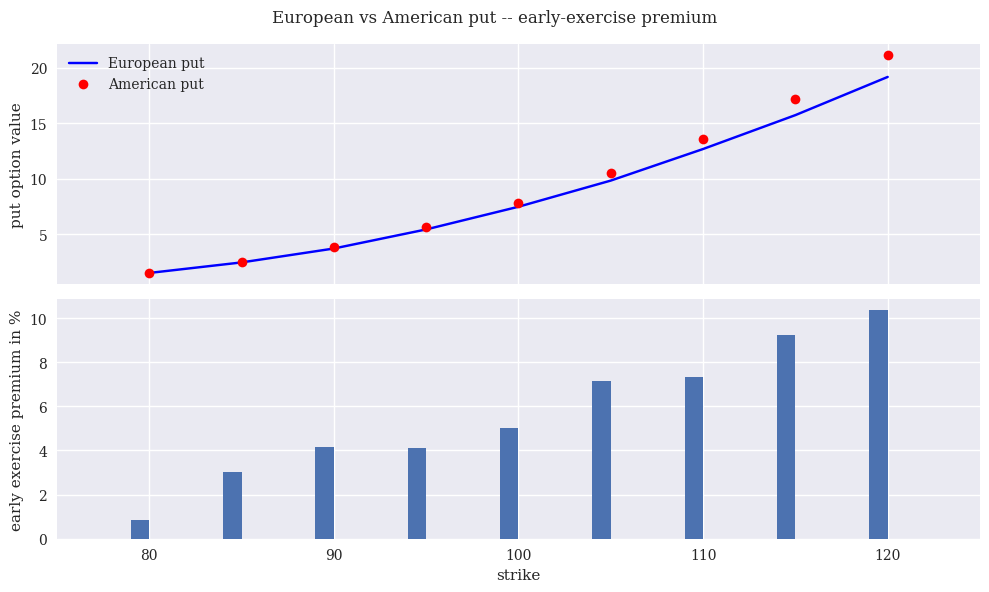

In [39]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 6))
ax1.plot(k_list, euro_res, 'b', label='European put')
ax1.plot(k_list, amer_res, 'ro', label='American put')
ax1.set_ylabel('put option value'); ax1.legend(loc=0)

wi = 1.0
ax2.bar(k_list - wi / 2,
        (amer_res - euro_res) / euro_res * 100, wi)
ax2.set_xlabel('strike'); ax2.set_ylabel('early exercise premium in %')
ax2.set_xlim(left=75, right=125)
plt.suptitle('European vs American put -- early-exercise premium')
plt.tight_layout(); plt.show()

**Figure 12-17.** European vs American put values and the resulting
early-exercise premium.

- Top panel: the American put dominates the European put **at every
  strike** (the red curve sits above the blue), as the option to exercise
  early is always weakly valuable.
- Bottom panel: the premium peaks at the lowest strike (deep OTM puts) and
  decays as we move ITM. For at-the-money puts the premium is in the
  $5$-$8\%$ range -- significant, and certainly not ignorable for a
  trading desk.

**Strategic takeaway.** When marking a book of American puts, valuing
them as Europeans introduces a bias of order $5$-$10\%$ -- enough to
materially mis-state P&L and risk. LSM, despite its small downward bias,
is the industry standard for handling this.

## 12.7 Risk Measures

### Value-at-Risk

**Value-at-Risk (VaR)** is the most widely used risk measure in finance,
notwithstanding well-known shortcomings. Informally:

> *VaR is the loss level that will not be exceeded with confidence
> $1 - \alpha$ over a horizon of $\Delta t$.*

Formally, for a P&L random variable $\Delta V$ over the horizon and a
confidence level $1 - \alpha$,

$$
\mathrm{VaR}_{\alpha}(\Delta V) \;=\; -\inf\big\{\, x : \mathbb{P}(\Delta V \le x) \ge \alpha\,\big\}.
$$

A 99% one-month VaR of $50{,}000$ USD on a position worth 1 million USD says:
*"with 99% probability, monthly P&L will be no worse than $-50{,}000$ USD."*
It does **not** say anything about how bad the loss might be in the
remaining 1% -- this is the so-called **tail risk** that VaR cannot capture
on its own.

We compute VaR by simulation under two models: GBM and the Merton
jump-diffusion. The horizon is $T = 30/365 \approx 0.0822$ years (one
month).

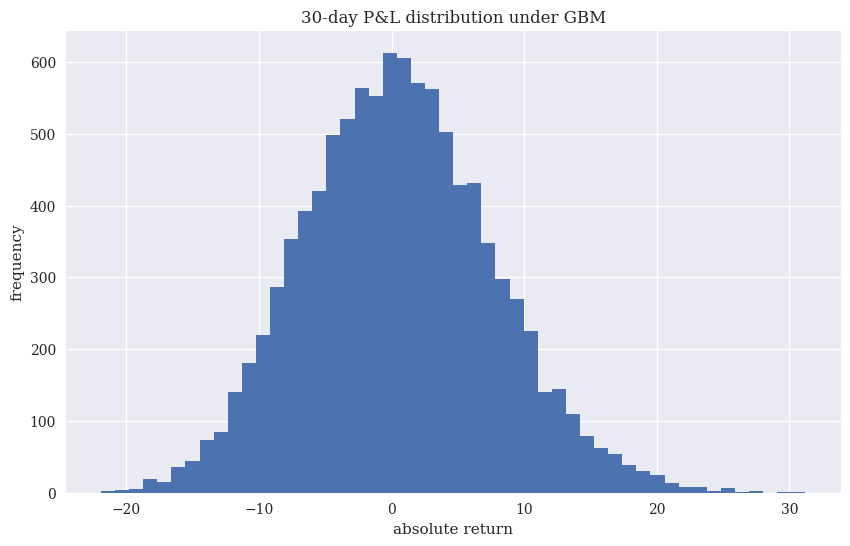

In [40]:
S0 = 100; r = 0.05; sigma = 0.25; T = 30 / 365.; I = 10000

# Static GBM simulation of S_T
ST = S0 * np.exp(
    (r - 0.5 * sigma ** 2) * T
    + sigma * np.sqrt(T) * npr.standard_normal(I)
)

# Sorted absolute P&L (loss = negative P&L)
R_gbm = np.sort(ST - S0)

plt.figure(figsize=(10, 6))
plt.hist(R_gbm, bins=50)
plt.xlabel('absolute return'); plt.ylabel('frequency')
plt.title('30-day P&L distribution under GBM')
plt.show()

**Figure 12-18.** Empirical distribution of 30-day absolute P&L under GBM.

The shape is approximately bell-curved -- because over a short 30-day
horizon, GBM log-returns are nearly Gaussian and the exponential map only
slightly skews the result. The mass is concentrated within roughly
$\pm 15$ currency units of zero.

Sorting the P&L lets us read off VaR as a percentile of the empirical
distribution.

In [41]:
percs = [0.01, 0.1, 1., 2.5, 5.0, 10.0]
var = scs.scoreatpercentile(R_gbm, percs)
print('%16s %16s' % ('Confidence Level', 'Value-at-Risk'))
print(33 * '-')
for pair in zip(percs, var):
    print('%16.2f %16.3f' % (100 - pair[0], -pair[1]))

Confidence Level    Value-at-Risk
---------------------------------
           99.99           21.814
           99.90           18.837
           99.00           15.230
           97.50           12.816
           95.00           10.824
           90.00            8.504


The table reads as follows. At confidence level $99.9\%$ ($\alpha = 0.001$,
i.e. the worst-1-in-1000 outcome), the simulated GBM 30-day VaR is about
$18.8$ currency units. At $99\%$ the VaR is about $15.2$, and at the
much-criticised $90\%$ level it is around $8.5$.

**Concretely:** if we hold one share priced at $S_0 = 100$, a $99.9\%$
30-day VaR of $18.8$ means there's a $0.1\%$ chance of losing more than
$\$18.80$ over the next 30 days under the GBM model.

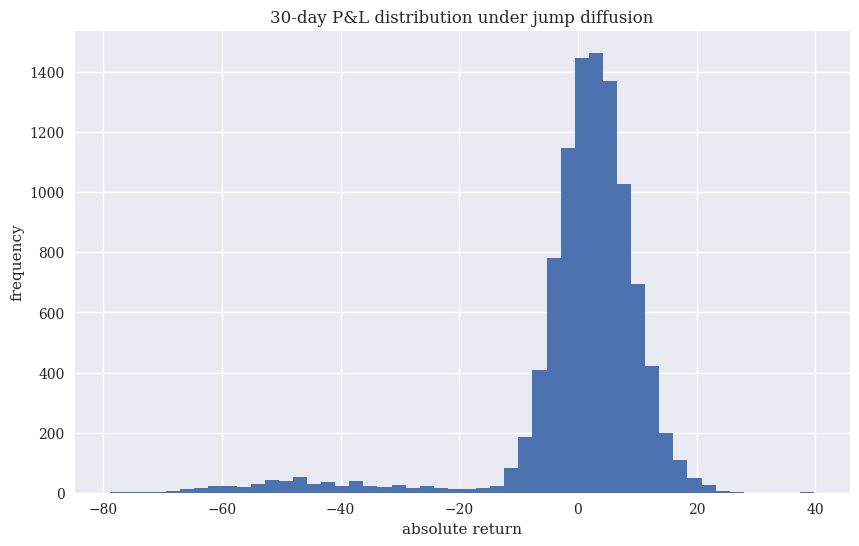

In [42]:
# Repeat with the Merton jump-diffusion -- same horizon, jump parameters from earlier
M = 50; I = 10000
T = 30 / 365.
dt = T / M
sigma = 0.2  # back to jump-diffusion's sigma
lamb = 0.75; mu = -0.6; delta = 0.25
rj = lamb * (math.exp(mu + 0.5 * delta ** 2) - 1)

S = np.zeros((M + 1, I)); S[0] = S0
sn1 = npr.standard_normal((M + 1, I))
sn2 = npr.standard_normal((M + 1, I))
poi = npr.poisson(lamb * dt, (M + 1, I))

for t in range(1, M + 1, 1):
    S[t] = S[t - 1] * (
        np.exp((r - rj - 0.5 * sigma ** 2) * dt
               + sigma * math.sqrt(dt) * sn1[t])
        + (np.exp(mu + delta * sn2[t]) - 1) * poi[t]
    )
    S[t] = np.maximum(S[t], 0)

R_jd = np.sort(S[-1] - S0)

plt.figure(figsize=(10, 6))
plt.hist(R_jd, bins=50)
plt.xlabel('absolute return'); plt.ylabel('frequency')
plt.title('30-day P&L distribution under jump diffusion')
plt.show()

**Figure 12-19.** Empirical 30-day P&L under jump diffusion.

A second mode is visible at large negative values -- the **fat left tail**
created by the negative-mean jump component. Over 30 days, the probability
of one-or-more jumps is $1 - e^{-\lambda T} = 1 - e^{-0.75 \cdot 30/365} \approx 5.9\%$,
and conditional on a jump the average log-move is $\mu_J = -0.6$ -- a
roughly $-45\%$ move in price.

This is the classic **risk-management failure mode of constant-volatility
GBM**: it underestimates the probability of extreme losses precisely
because it assumes returns are Gaussian.

In [43]:
percs = [0.01, 0.1, 1., 2.5, 5.0, 10.0]
var_jd = scs.scoreatpercentile(R_jd, percs)
print('%16s %16s' % ('Confidence Level', 'Value-at-Risk'))
print(33 * '-')
for pair in zip(percs, var_jd):
    print('%16.2f %16.3f' % (100 - pair[0], -pair[1]))

Confidence Level    Value-at-Risk
---------------------------------
           99.99           76.164
           99.90           68.665
           99.00           55.633
           97.50           46.285
           95.00           24.483
           90.00            6.574


Under jump diffusion the $99.9\%$ VaR rises to roughly **$68.7$**
currency units -- *more than three times* the GBM number ($18.8$). At the
$99.99\%$ tail the gap is even more dramatic ($76.2$ vs $21.8$).

At the $90\%$ level, by contrast, the JD VaR is about **$6.6$** -- *lower*
than the GBM value of $8.5$. The two distributions actually **cross**:
JD reassigns probability mass from moderate losses (the bulk of the GBM
bell) into the *extremes* (the jump tail), so the body of the JD
distribution is *narrower* than GBM, even though its tail is much
heavier.

This is the central insight: **VaR at moderate confidence levels can be
lower under a fat-tailed model**; only at extreme confidence levels does
the tail risk show up. Choosing a too-lenient confidence level renders
VaR a poor guide to extreme losses -- and worse, can give the misleading
impression that a fat-tailed exposure is *safer* than a Gaussian one.

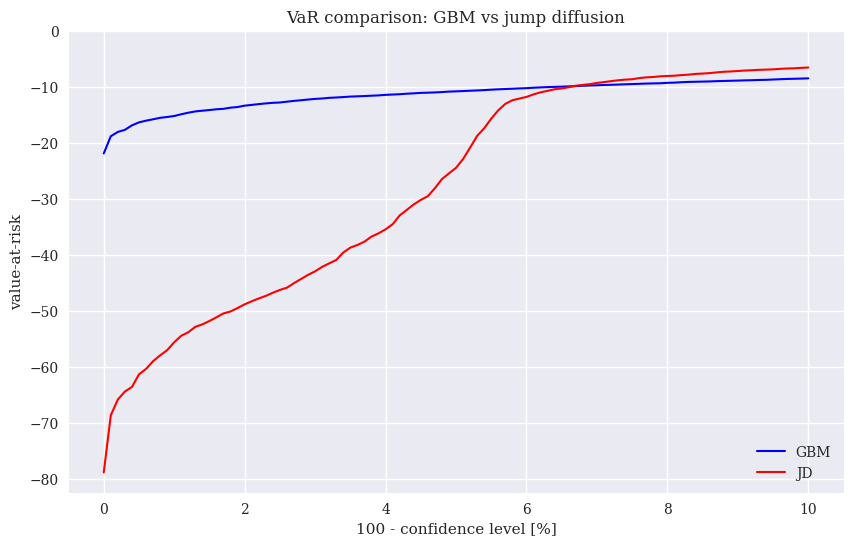

In [44]:
# Direct comparison plot
percs = list(np.arange(0.0, 10.1, 0.1))
gbm_var = scs.scoreatpercentile(R_gbm, percs)
jd_var = scs.scoreatpercentile(R_jd, percs)

plt.figure(figsize=(10, 6))
plt.plot(percs, gbm_var, 'b', lw=1.5, label='GBM')
plt.plot(percs, jd_var, 'r', lw=1.5, label='JD')
plt.legend(loc=4)
plt.xlabel('100 - confidence level [%]')
plt.ylabel('value-at-risk')
plt.ylim(top=0.0)
plt.title('VaR comparison: GBM vs jump diffusion')
plt.show()

**Figure 12-20.** VaR curves for GBM and jump diffusion across confidence
levels. Note that the y-axis is the *signed* P&L percentile, so deeper
losses are *more negative*; the actual VaR magnitude is $-\text{(plotted value)}$.

The two curves **cross**: on the right side of the plot (low confidence
$\sim 90\%$, the right tail of the loss distribution) the GBM curve is
*deeper* than JD, because GBM has a wider central mass. Moving left
(toward higher confidence levels), the curves cross around the $97$th-$98$th
percentile, and at extreme confidence levels ($\geq 99\%$) the JD curve
plunges much further below GBM.

**Production interpretation.** Two firms could report identical $90\%$ VaR
numbers for the same position while having radically different exposure
to tail events -- in fact, the firm using a fat-tailed model could even
report a *smaller* $90\%$ VaR while being *more* exposed to crashes. This
is exactly why post-crisis risk frameworks (Basel 2.5/3) supplement VaR
with **Expected Shortfall** (the mean loss conditional on being worse
than VaR), which by construction integrates the shape of the tail rather
than relying on a single quantile.

### Credit Value-at-Risk and Credit Valuation Adjustment

**Credit Value-at-Risk (CVaR)** measures the risk of loss arising from a
counterparty defaulting on its obligations. Its expectation under the
risk-neutral measure is the **Credit Valuation Adjustment (CVA)** -- a
charge that reduces the no-default value of a claim:

$$
V_0^{\text{adj}} \;=\; V_0^{\text{no default}} \;-\; \mathrm{CVA}.
$$

In the simplest setting we model:

- a fixed loss-given-default $L$ (a fraction of exposure),
- a fixed default probability $p$ per year,
- defaults arriving as a Poisson process (so at most one default in our
  one-year horizon).

We will compute CVaR/CVA for two exposures: a long stock position and a
European call option, both on the same underlying.

In [45]:
# Reset to the BSM benchmark setup
S0 = 100.; r = 0.05; sigma = 0.2; T = 1.; I = 100000

ST = S0 * np.exp(
    (r - 0.5 * sigma ** 2) * T
    + sigma * np.sqrt(T) * npr.standard_normal(I)
)

L = 0.5     # loss-given-default = 50%
p = 0.01    # default probability = 1% per year

# Simulate default events; cap at 1 per path
D = npr.poisson(p * T, I)
D = np.where(D > 1, 1, D)

print(f'Total simulated defaults: {D.sum()}')
print(f'Default rate in sample  : {D.sum()/I:.4%}  (target {p:.4%})')

Total simulated defaults: 978
Default rate in sample  : 0.9780%  (target 1.0000%)


With $I = 100{,}000$ paths and $p = 1\%$ we expect about $1000$ defaults
in the sample. The realised count is **978** -- close to expectation
within Poisson sampling fluctuation. We cap defaults at one per path
because Bermuda-style multiple defaults of the same counterparty don't
make economic sense in this setup.

In [46]:
# CVaR and adjusted asset values
print(f'Discounted mean S_T (no-default): {math.exp(-r * T) * np.mean(ST):.6f}')

CVaR_stock = math.exp(-r * T) * np.mean(L * D * ST)
print(f'CVaR (stock)                    : {CVaR_stock:.6f}')

S0_CVA = math.exp(-r * T) * np.mean((1 - L * D) * ST)
print(f'Default-adjusted value           : {S0_CVA:.6f}')

S0_adj = S0 - CVaR_stock
print(f'Initial value minus CVaR         : {S0_adj:.6f}')

Discounted mean S_T (no-default): 99.947672
CVaR (stock)                    : 0.488356
Default-adjusted value           : 99.459316
Initial value minus CVaR         : 99.511644


**Stock CVA -- four numbers, three insights:**

1. The discounted no-default mean of $S_T$ is approximately **$99.95$**,
   essentially equal to $S_0 = 100$ (any deviation is sampling noise --
   under $Q$, $\mathbb{E}^Q[e^{-rT} S_T] = S_0$ by martingality).
2. The **CVaR is about $0.49$** -- roughly $0.49\%$ of notional. We can
   sanity-check this against the closed-form
   $\mathrm{CVaR} \approx L \cdot p \cdot S_0 = 0.5 \cdot 0.01 \cdot 100 = 0.50$.
   Our simulation matches to within Monte Carlo noise.
3. The **default-adjusted value** is $99.95 - 0.49 \approx 99.46$, which
   matches `S0_CVA` from the simulation. Equivalently, $S_0 - \mathrm{CVaR} \approx 99.51$
   -- about $0.05$ off due to sampling noise (the difference comes from
   the fact that the discounted mean of $S_T$ is itself an estimator,
   not exactly $S_0$).

These two formulations of "value adjusted for credit risk" disagree at
order $10^{-1}$: significant for accounting (CVA charges run into millions
on real books), insignificant for academic exposition.

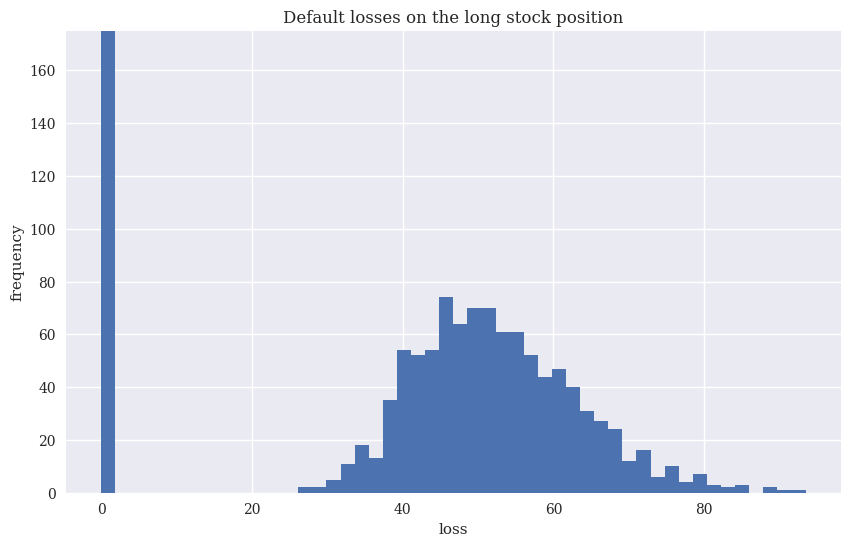

In [47]:
plt.figure(figsize=(10, 6))
plt.hist(L * D * ST, bins=50)
plt.xlabel('loss'); plt.ylabel('frequency')
plt.ylim(top=175)
plt.title('Default losses on the long stock position')
plt.show()

**Figure 12-21.** Histogram of default losses for the long stock position.

We zoom the y-axis to focus on the tail because the dominant bin
($\approx 99{,}022$ no-default paths with zero loss) would otherwise
crush every other bar to invisibility. The visible distribution covers
all default scenarios: a rough log-normal centred near
$L \cdot S_0 \cdot e^{rT} \approx 0.5 \cdot 105 \approx 52.5$, with both
tails reflecting the variation in $S_T$ across paths that happened to
default.

In [48]:
# CVA for a European call instead of the stock
K = 100.
hT = np.maximum(ST - K, 0)

C0 = math.exp(-r * T) * np.mean(hT)
print(f'European call price (no default)   : {C0:.6f}')

CVaR_call = math.exp(-r * T) * np.mean(L * D * hT)
print(f'CVaR (call)                         : {CVaR_call:.6f}')

C0_CVA = math.exp(-r * T) * np.mean((1 - L * D) * hT)
print(f'Default-adjusted call price         : {C0_CVA:.6f}')

print()
print(f'CVaR as % of call price            : {CVaR_call / C0 * 100:.2f}%')
print(f'CVaR as % of stock price           : {CVaR_stock / S0 * 100:.2f}%')

European call price (no default)   : 10.396916
CVaR (call)                         : 0.051591
Default-adjusted call price         : 10.345325

CVaR as % of call price            : 0.50%
CVaR as % of stock price           : 0.49%


**Call CVA observations:**

- The European call is worth about **$10.40$** ignoring credit (close to
  the BSM analytical price for these parameters).
- The CVaR is about **$0.052$** -- only $\sim 0.5\%$ of the option value,
  but **proportionally similar to the stock CVaR** (both are around
  $0.5\%$ of their respective notionals).
- The default-adjusted call is **$10.35$**.

The proportional similarity is no coincidence: the CVaR is approximately
$L \cdot p \cdot V_0$ for any exposure $V_0$, so the *relative* CVA is
roughly $L \cdot p = 0.5\%$ regardless of the underlying claim. The
*absolute* CVA scales with the value of the claim.

Number of defaults                       : 978
Number of defaults *and* call payoff > 0 : 538
Number of paths with zero call payoff    : 44123


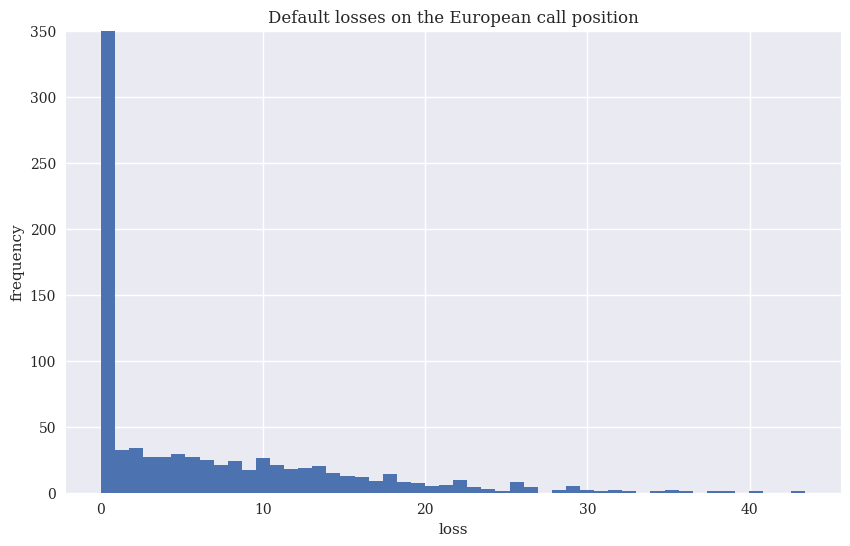

In [49]:
# How many of the default events generated an option-side loss?
n_defaults = int(np.count_nonzero(D))
n_option_losses = int(np.count_nonzero(L * D * hT))
n_zero_payoff = int(I - np.count_nonzero(hT))

print(f'Number of defaults                       : {n_defaults}')
print(f'Number of defaults *and* call payoff > 0 : {n_option_losses}')
print(f'Number of paths with zero call payoff    : {n_zero_payoff}')

plt.figure(figsize=(10, 6))
plt.hist(L * D * hT, bins=50)
plt.xlabel('loss'); plt.ylabel('frequency')
plt.ylim(top=350)
plt.title('Default losses on the European call position')
plt.show()

**Figure 12-22.** Default losses on the European call.

A subtle but important point: out of $\approx 978$ defaults, only about
**538** create a non-zero loss for the call holder. The remaining
$\approx 440$ defaults occur on paths where the call expires
out-of-the-money ($S_T \le K$), so the would-be exposure was zero anyway.
About **$44{,}123$** of the $100{,}000$ paths see the call expire
worthless even without default.

**Strategic takeaway.** The credit risk of an option is generically
*lower* than the credit risk of the underlying because exposure is
contingent on the option being in-the-money. CVA models in production
take this into account -- and their accuracy depends critically on
modelling the **wrong-way risk** correlation between counterparty default
and the underlying's value, which our toy independent-default model
ignores.

## 12.8 Conclusion

This chapter assembled a working toolkit for stochastic finance in Python:

1. **Random number generation.** We sampled from uniform, normal,
   chi-square, Poisson, and log-normal distributions using `numpy.random`.
2. **Stochastic process simulation.** We discretised four canonical
   processes -- geometric Brownian motion, the CIR square-root diffusion
   (both Euler and exact schemes), Heston stochastic volatility with
   correlated factors, and Merton jump-diffusion.
3. **Variance reduction.** Antithetic variates and moment matching gave us
   exact first- and second-moment matching at no computational cost.
4. **Option valuation.** European options were priced by both static and
   dynamic Monte Carlo and benchmarked against the analytical BSM formula.
   American options were priced by the Longstaff-Schwartz Least-Squares
   Monte Carlo algorithm.
5. **Risk measures.** Value-at-Risk under GBM and jump diffusion exposed
   the tail-risk blindspot of constant-volatility models. Credit
   valuation adjustments captured the cost of counterparty default risk
   for both linear and convex exposures.

**The unifying theme.** NumPy's vectorised primitives -- `standard_normal`,
`poisson`, `noncentral_chisquare`, plus broadcasting and `np.dot` -- make
each of these techniques implementable in tens of lines of Python while
running at near-C speeds. This is why simulation has become the workhorse
of modern financial engineering.

**What we did not cover.** Quasi-random numbers (Sobol, Halton sequences),
which can dramatically reduce the sample-size dependence of low-dimensional
integrals. Importance sampling, control variates, and stratification --
more powerful variance-reduction techniques than the two we discussed.
GPU acceleration via CuPy/JAX. Calibration of the Heston and Merton models
to market option prices. These are natural next steps and topics of later
chapters.

---

## Appendix -- `bsm_functions.py`

The book ships a separate module `bsm_functions.py` containing analytical
BSM utilities. We reproduce it here for reference; the contents define
`bsm_call_value`, `bsm_vega`, and `bsm_call_imp_vol`. In Colab, you can
save this cell as a `.py` file with `%%writefile bsm_functions.py` for
re-use across notebooks.

```python
def bsm_call_value(S0, K, T, r, sigma):
    '''Valuation of European call option in BSM model. Analytical formula.'''
    from math import log, sqrt, exp
    from scipy import stats
    S0 = float(S0)
    d1 = (log(S0 / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * sqrt(T))
    d2 = (log(S0 / K) + (r - 0.5 * sigma ** 2) * T) / (sigma * sqrt(T))
    value = (S0 * stats.norm.cdf(d1, 0.0, 1.0)
             - K * exp(-r * T) * stats.norm.cdf(d2, 0.0, 1.0))
    return value


def bsm_vega(S0, K, T, r, sigma):
    '''Vega of European option in BSM model.'''
    from math import log, sqrt
    from scipy import stats
    S0 = float(S0)
    d1 = (log(S0 / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * sqrt(T))
    vega = S0 * stats.norm.pdf(d1, 0.0, 1.0) * sqrt(T)
    return vega


def bsm_call_imp_vol(S0, K, T, r, C0, sigma_est, it=100):
    '''Implied volatility of European call by Newton iteration on BSM.'''
    for i in range(it):
        sigma_est -= ((bsm_call_value(S0, K, T, r, sigma_est) - C0)
                      / bsm_vega(S0, K, T, r, sigma_est))
    return sigma_est
```

The Newton-Raphson iteration in `bsm_call_imp_vol` solves
$\mathrm{BSM}(\sigma) = C_0^{\text{market}}$ for $\sigma$ -- i.e. it
extracts the **implied volatility** that reproduces a quoted option price.
The update rule

$$
\sigma_{n+1} \;=\; \sigma_n \;-\; \frac{\mathrm{BSM}(\sigma_n) - C_0}{\mathrm{vega}(\sigma_n)}
$$

uses vega (the partial derivative of BSM with respect to volatility) as
the local linear approximation. With a reasonable starting guess (e.g.
$0.2$) this converges in just a handful of iterations.